# 0. Reproducible Figure Notebook

This notebook regenerates the figures used in our final HTML blog post from saved model outputs. Each cell uses our saved XGBoost and GNN pipeline outputs to a folder in our repo. 

The notebook loads:
- raw mutation data from `single_point_mutations.tsv`
- saved XGBoost outputs from `results/xgboost/`
- saved GNN outputs from `results/`
- saved graph/example assets from `assets/`

All final blog-ready figures are saved to `assets/figures/` and referenced by `index.html` for our blog submission.

# 1. Imports, etc.

In [65]:
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib import colors as mcolors
import math 
from matplotlib.lines import Line2D

In [15]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    markers = [
        "single_point_mutations.tsv",
        "results",
        "assets",
    ]

    for path in [start] + list(start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        "Could not find project root. Please run this notebook from inside the aml-final-project repo."
    )

PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results"
XGB_RESULTS_DIR = RESULTS_DIR / "xgboost"
ASSETS_DIR = PROJECT_ROOT / "assets"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("ASSETS_DIR exists:", ASSETS_DIR.exists())

PROJECT_ROOT: /Users/zoyakhan/Documents/GitHub/aml-final-project
RESULTS_DIR exists: True
ASSETS_DIR exists: True


In [71]:
(PROJECT_ROOT / "assets" / "figures").mkdir(parents=True, exist_ok=True)

# 2. Preliminary data exploration plots

### 1. Load TSV + rebuild df used for prelim. analysis

In [16]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "single_point_mutations.tsv"

table = pd.read_csv(DATA_PATH, sep="\t")

table["TYPE"] = [
    "PDB" if "PDB" in str(x) else "UniProt" if "UniProt" in str(x) else "Unknown"
    for x in table["MUTATION"]
]
table = table[table["TYPE"] != "Unknown"].copy()

table_uniprot = table[table["TYPE"] == "UniProt"].copy()

aa_properties = {
    "A": {"hydrophobicity": 0.61, "charge": 0, "weight": 89.09},
    "R": {"hydrophobicity": 0.60, "charge": 1, "weight": 174.20},
    "N": {"hydrophobicity": 0.06, "charge": 0, "weight": 132.12},
    "D": {"hydrophobicity": 0.46, "charge": -1, "weight": 133.10},
    "C": {"hydrophobicity": 1.07, "charge": 0, "weight": 121.15},
    "Q": {"hydrophobicity": 0.00, "charge": 0, "weight": 146.15},
    "E": {"hydrophobicity": 0.47, "charge": -1, "weight": 147.13},
    "G": {"hydrophobicity": 0.07, "charge": 0, "weight": 75.07},
    "H": {"hydrophobicity": 0.61, "charge": 0, "weight": 155.16},
    "I": {"hydrophobicity": 2.22, "charge": 0, "weight": 131.17},
    "L": {"hydrophobicity": 1.53, "charge": 0, "weight": 131.17},
    "K": {"hydrophobicity": 1.15, "charge": 1, "weight": 146.19},
    "M": {"hydrophobicity": 1.18, "charge": 0, "weight": 149.21},
    "F": {"hydrophobicity": 2.02, "charge": 0, "weight": 165.19},
    "P": {"hydrophobicity": 1.95, "charge": 0, "weight": 115.13},
    "S": {"hydrophobicity": 0.05, "charge": 0, "weight": 105.09},
    "T": {"hydrophobicity": 0.05, "charge": 0, "weight": 119.12},
    "W": {"hydrophobicity": 2.65, "charge": 0, "weight": 204.24},
    "Y": {"hydrophobicity": 1.88, "charge": 0, "weight": 181.19},
    "V": {"hydrophobicity": 1.32, "charge": 0, "weight": 117.15},
}

table_uniprot_xgb = table_uniprot.copy()
table_uniprot_xgb["WT_AA"] = table_uniprot_xgb["MUTATION"].apply(lambda x: str(x).split()[0][0])
table_uniprot_xgb["MUT_AA"] = table_uniprot_xgb["MUTATION"].apply(lambda x: str(x).split()[0][-1])
table_uniprot_xgb["POSITION"] = table_uniprot_xgb["MUTATION"].apply(lambda x: int(str(x).split()[0][1:-1]))

table_uniprot_xgb = table_uniprot_xgb[
    table_uniprot_xgb["WT_AA"].isin(aa_properties) &
    table_uniprot_xgb["MUT_AA"].isin(aa_properties)
].copy()

table_uniprot_xgb["delta_hydrophobicity"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["hydrophobicity"] - aa_properties[row["WT_AA"]]["hydrophobicity"],
    axis=1,
)
table_uniprot_xgb["delta_charge"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["charge"] - aa_properties[row["WT_AA"]]["charge"],
    axis=1,
)
table_uniprot_xgb["delta_weight"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["weight"] - aa_properties[row["WT_AA"]]["weight"],
    axis=1,
)

table_uniprot_xgb["∆∆G_(kcal/mol)"] = pd.to_numeric(table_uniprot_xgb["∆∆G_(kcal/mol)"], errors="coerce")
table_uniprot_xgb = table_uniprot_xgb.dropna(subset=["∆∆G_(kcal/mol)"]).copy()

one_hot_wt = pd.get_dummies(table_uniprot_xgb["WT_AA"], prefix="WT")
one_hot_mut = pd.get_dummies(table_uniprot_xgb["MUT_AA"], prefix="MUT")
table_uniprot_xgb = pd.concat([table_uniprot_xgb, one_hot_wt, one_hot_mut], axis=1)

print("table_uniprot_xgb shape:", table_uniprot_xgb.shape)
print("unique proteins:", table_uniprot_xgb["PROTEIN"].nunique())
display(table_uniprot_xgb.head())

table_uniprot_xgb shape: (496, 66)
unique proteins: 46


,NO,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,SEC_STR,ASA,pH,...,MUT_M,MUT_N,MUT_P,MUT_Q,MUT_R,MUT_S,MUT_T,MUT_V,MUT_W,MUT_Y
0,176,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,True,False,False,False,False,False,False,False,False
1,177,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,False,False,True,False,False,False,False,False,False
2,178,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,True,False,False,False,False,False,False,False,False
3,179,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,False,False,True,False,False,False,False,False,False
4,181,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,6.0,...,False,True,False,False,False,False,False,False,False,False


### 2. ΔΔG distribution

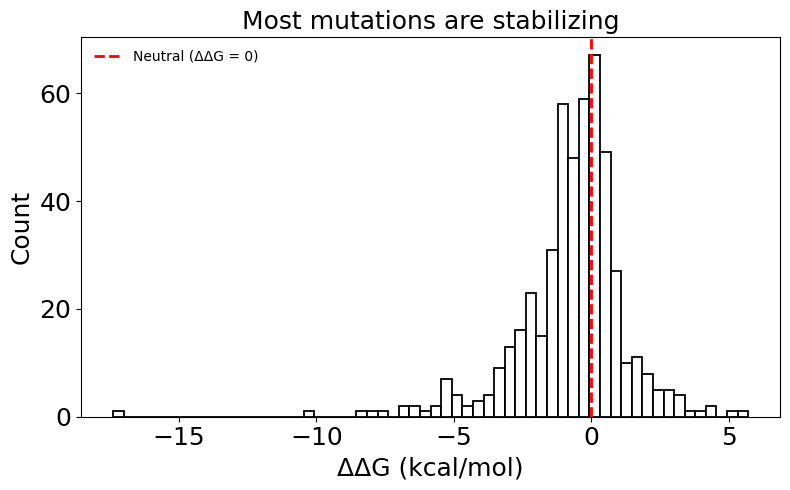

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    table_uniprot_xgb["∆∆G_(kcal/mol)"],
    bins=60,
    edgecolor="black",
    linewidth=1.3,
    color="white",
)

ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Neutral (ΔΔG = 0)")
ax.set_xlabel("ΔΔG (kcal/mol)", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.tick_params(axis="both", labelsize=18)
ax.set_title("Most mutations are stabilizing", fontsize=18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 3. Substitution heatmap

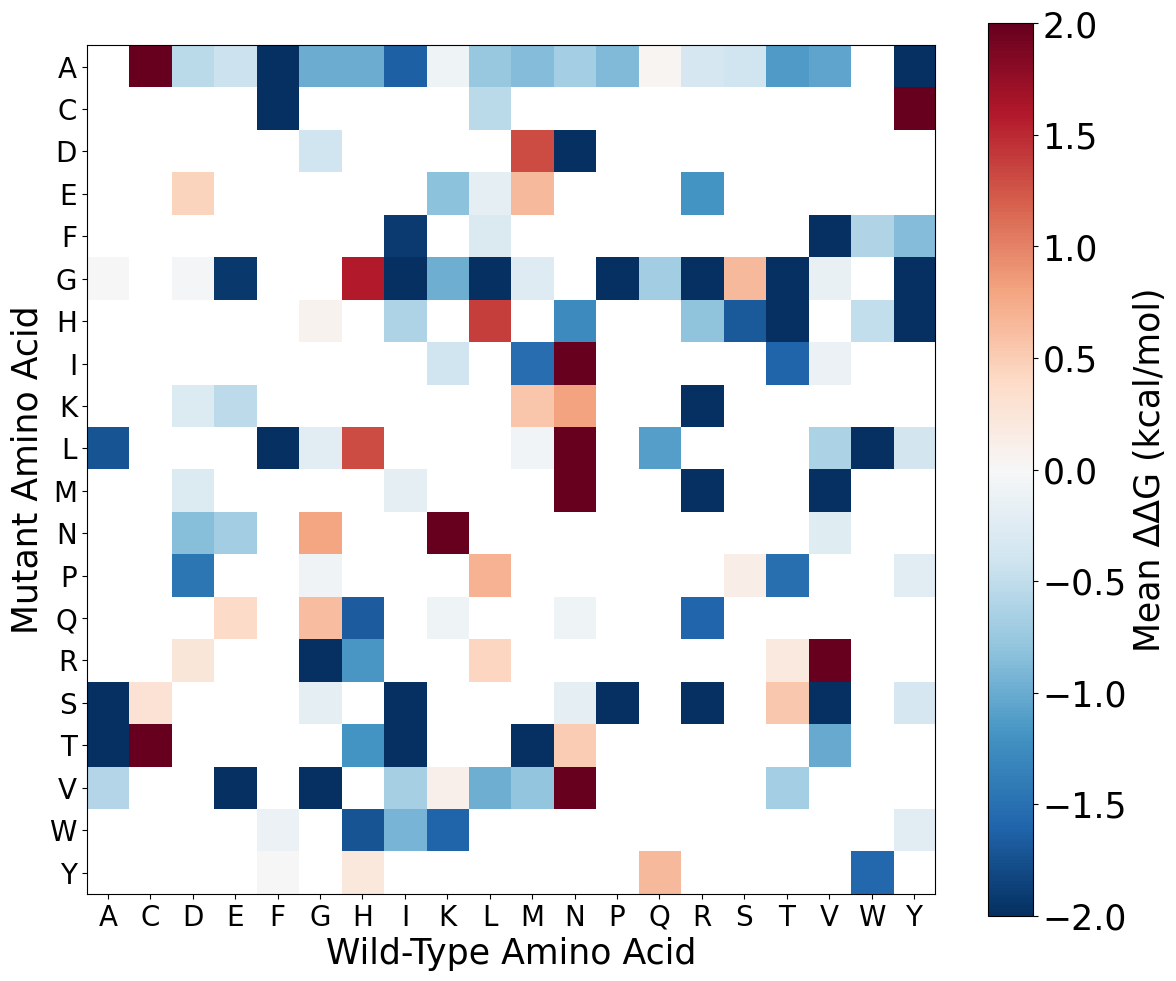

In [18]:
amino_acids = sorted(set(table_uniprot_xgb["WT_AA"]).union(set(table_uniprot_xgb["MUT_AA"])))
matrix = pd.DataFrame(index=amino_acids, columns=amino_acids, dtype=float)

for mut in amino_acids:
    for wt in amino_acids:
        subset = table_uniprot_xgb[
            (table_uniprot_xgb["WT_AA"] == wt) &
            (table_uniprot_xgb["MUT_AA"] == mut)
        ]["∆∆G_(kcal/mol)"]
        matrix.loc[mut, wt] = subset.mean() if len(subset) > 0 else np.nan

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(matrix.values.astype(float), cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_xticks(range(len(amino_acids)))
ax.set_yticks(range(len(amino_acids)))
ax.set_xticklabels(amino_acids, fontsize=20)
ax.set_yticklabels(amino_acids, fontsize=20)

ax.set_xlabel("Wild-Type Amino Acid", fontsize=25)
ax.set_ylabel("Mutant Amino Acid", fontsize=25)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean ΔΔG (kcal/mol)", fontsize=25)
cbar.ax.tick_params(labelsize=25)

plt.tight_layout()
plt.show()

### 4. Charge-change boxplot

/var/folders/gd/_r05n4z510b8fwkl302p302w0000gn/T/ipykernel_53615/558611072.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=13)


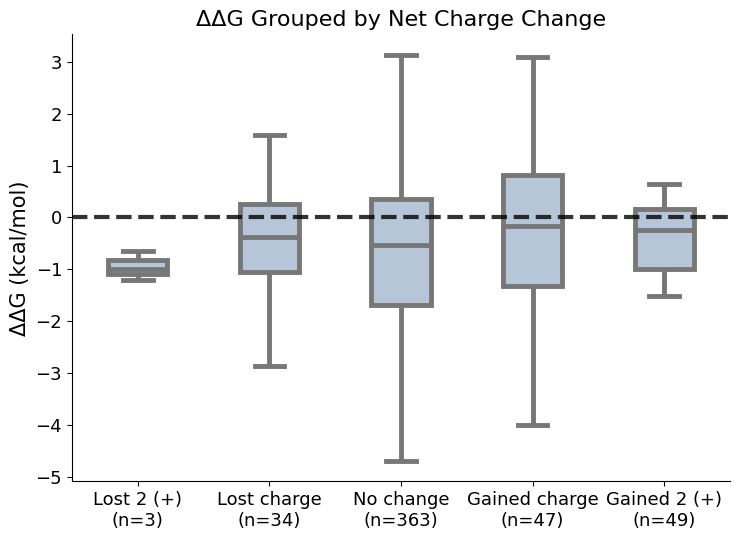

In [19]:
charge_labels = {
    -2: "Lost 2 (+)",
    -1: "Lost charge",
    0: "No change",
    1: "Gained charge",
    2: "Gained 2 (+)",
}
charge_order = [-2, -1, 0, 1, 2]

plot_df = table_uniprot_xgb[["delta_charge", "∆∆G_(kcal/mol)"]].copy()
plot_df = plot_df[plot_df["delta_charge"].isin(charge_order)].copy()

counts = plot_df["delta_charge"].value_counts().reindex(charge_order).fillna(0).astype(int)
tick_labels = [f"{charge_labels[k]}\n(n={counts[k]})" for k in charge_order]

plot_df["Charge Category"] = pd.Categorical(plot_df["delta_charge"], categories=charge_order, ordered=True)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

sns.boxplot(
    data=plot_df,
    x="Charge Category",
    y="∆∆G_(kcal/mol)",
    order=charge_order,
    width=0.45,
    showfliers=False,
    ax=ax,
    color="lightsteelblue",
    linewidth=3.5,
)

ax.axhline(0, color="black", linestyle="--", linewidth=3, alpha=0.8)
ax.set_xticklabels(tick_labels, fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("ΔΔG (kcal/mol)", fontsize=15)
ax.set_title("ΔΔG Grouped by Net Charge Change", fontsize=16)
ax.tick_params(axis="y", labelsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 5. Feature-correlation heatmap

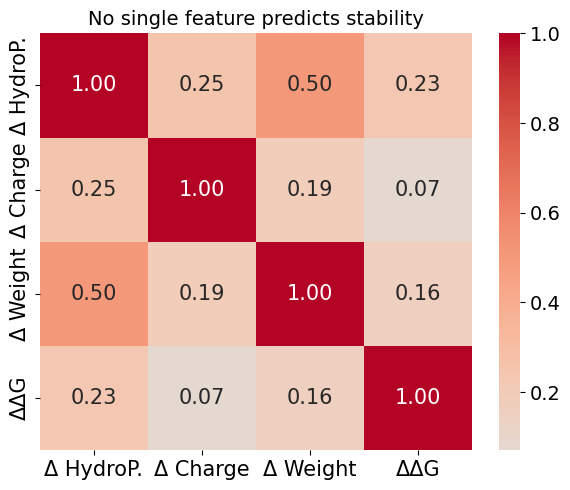

In [20]:
features = ["delta_hydrophobicity", "delta_charge", "delta_weight", "∆∆G_(kcal/mol)"]
corr = table_uniprot_xgb[features].corr()

fig, ax = plt.subplots(figsize=(6, 5))

hm = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 15},
    xticklabels=["Δ HydroP.", "Δ Charge", "Δ Weight", "ΔΔG"],
    yticklabels=["Δ HydroP.", "Δ Charge", "Δ Weight", "ΔΔG"],
    ax=ax,
)

ax.set_title("No single feature predicts stability", fontsize=14)
ax.tick_params(axis="both", labelsize=15)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# 3. XGBoost baseline plots

### 1. Load saved XGBoost outputs

In [21]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
XGB_RESULTS_DIR = RESULTS_DIR / "xgboost"
ASSETS_DIR = PROJECT_ROOT / "assets"

XGB_RUN_TAG = "xgb_prototype"

xgb_metrics = pd.read_csv(XGB_RESULTS_DIR / f"xgb_split_metrics_{XGB_RUN_TAG}.csv")
xgb_predictions = pd.read_csv(XGB_RESULTS_DIR / f"xgb_predictions_{XGB_RUN_TAG}.csv")
xgb_training_curves = pd.read_csv(XGB_RESULTS_DIR / f"xgb_training_curves_{XGB_RUN_TAG}.csv")
xgb_feature_importance = pd.read_csv(XGB_RESULTS_DIR / f"xgb_feature_importance_{XGB_RUN_TAG}.csv")
xgb_hyperparameter_search = pd.read_csv(XGB_RESULTS_DIR / f"xgb_hyperparameter_search_{XGB_RUN_TAG}.csv")

best_config_path = XGB_RESULTS_DIR / f"xgb_best_config_{XGB_RUN_TAG}.json"
if best_config_path.exists():
    with open(best_config_path, "r") as f:
        xgb_best_config = json.load(f)
else:
    xgb_best_config = None

print("Loaded XGBoost files:")
print("metrics:", xgb_metrics.shape)
print("predictions:", xgb_predictions.shape)
print("training curves:", xgb_training_curves.shape)
print("feature importance:", xgb_feature_importance.shape)
print("hyperparameter search:", xgb_hyperparameter_search.shape)

display(xgb_metrics)
display(xgb_hyperparameter_search)

Loaded XGBoost files:
metrics: (6, 10)
predictions: (992, 52)
training curves: (274, 5)
feature importance: (86, 3)
hyperparameter search: (5, 6)


,model,split_strategy,set,rmse,r,n,best_iteration,max_depth,learning_rate,n_estimators
0,XGBoost,Per-Mutation,train,1.582088,0.731667,282,29,6,0.05,300
1,XGBoost,Per-Mutation,val,1.616716,0.425898,95,29,6,0.05,300
2,XGBoost,Per-Mutation,test,1.775668,0.396912,119,29,6,0.05,300
3,XGBoost,Protein-Level,train,1.021302,0.754311,275,36,6,0.05,300
4,XGBoost,Protein-Level,val,3.128982,0.092027,123,36,6,0.05,300
5,XGBoost,Protein-Level,test,1.805585,0.198781,98,36,6,0.05,300


,max_depth,learning_rate,n_estimators,val_r,val_rmse,best_iteration
0,3,0.05,300,0.402764,1.638186,61
1,4,0.05,300,0.425804,1.617409,35
2,6,0.05,300,0.425898,1.616716,29
3,4,0.01,300,0.418368,1.622493,206
4,4,0.10,300,0.414649,1.631258,27


### 2. 4-panel XGBoost comparison

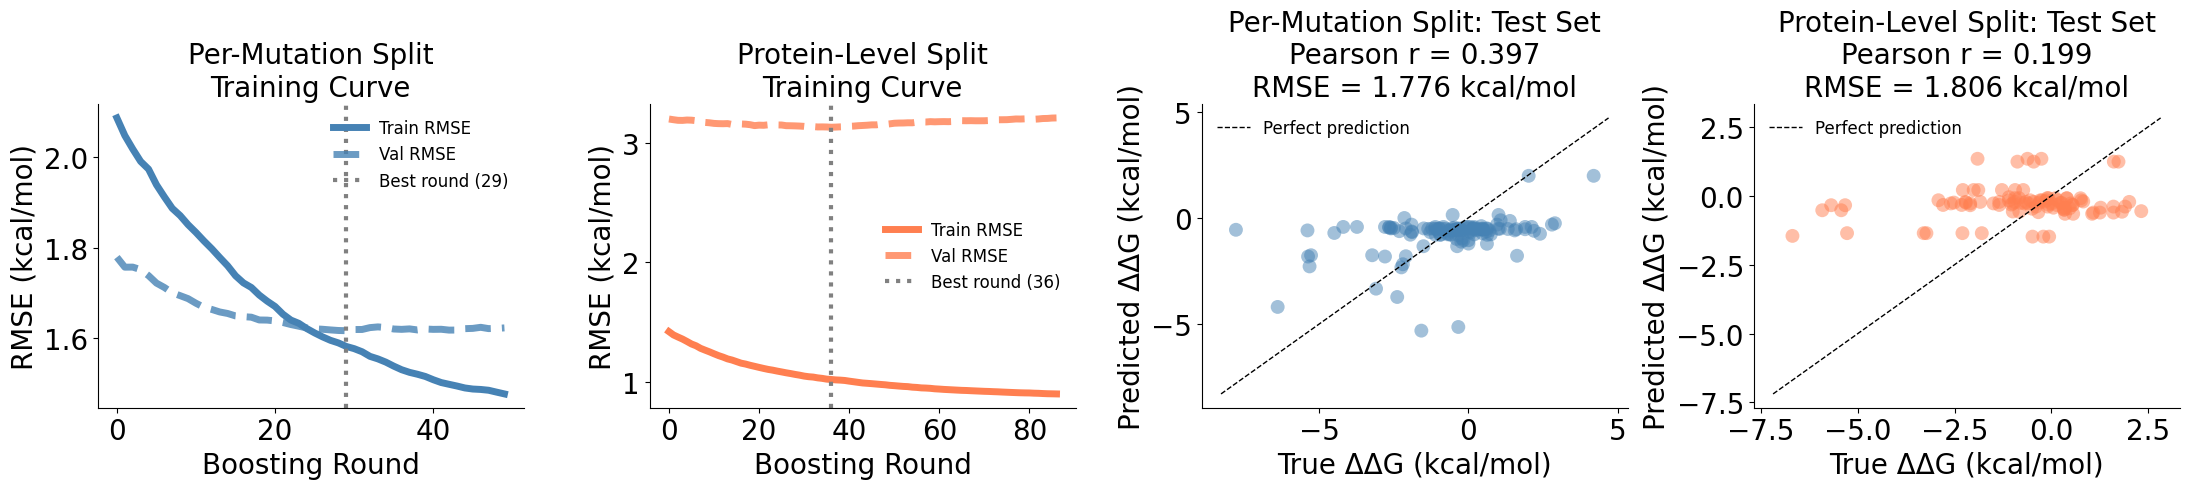

In [72]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

colors = {"Per-Mutation": "steelblue", "Protein-Level": "coral"}

for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i]

    train_curve = (
        xgb_training_curves[
            (xgb_training_curves["split_strategy"] == split_name) &
            (xgb_training_curves["set"] == "train")
        ]
        .sort_values("epoch")
    )

    val_curve = (
        xgb_training_curves[
            (xgb_training_curves["split_strategy"] == split_name) &
            (xgb_training_curves["set"] == "val")
        ]
        .sort_values("epoch")
    )

    best_round = int(train_curve["best_iteration"].dropna().iloc[0])

    ax.plot(train_curve["epoch"], train_curve["rmse"], color=col, linestyle="-", label="Train RMSE", linewidth=5)
    ax.plot(val_curve["epoch"], val_curve["rmse"], color=col, linestyle="--", label="Val RMSE", linewidth=5, alpha=0.8)
    ax.axvline(best_round, color="gray", linestyle=":", linewidth=3, label=f"Best round ({best_round})")

    ax.set_xlabel("Boosting Round", fontsize=20)
    ax.set_ylabel("RMSE (kcal/mol)", fontsize=20)
    ax.set_title(f"{split_name} Split\nTraining Curve", fontsize=20)
    ax.legend(fontsize=12, frameon=False)
    ax.tick_params(axis="both", labelsize=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i + 2]

    test_preds = (
        xgb_predictions[
            (xgb_predictions["split_strategy"] == split_name) &
            (xgb_predictions["set"] == "test")
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_true = test_preds["y_true"].to_numpy(dtype=float)
    y_pred = test_preds["y_pred"].to_numpy(dtype=float)

    r = pearsonr(y_true, y_pred)[0] if len(y_true) > 2 else np.nan
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    ax.scatter(y_true, y_pred, alpha=0.5, s=100, color=col, edgecolors="none")

    lims = [
        min(y_true.min(), y_pred.min()) - 0.5,
        max(y_true.max(), y_pred.max()) + 0.5,
    ]

    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("True ΔΔG (kcal/mol)", fontsize=20)
    ax.set_ylabel("Predicted ΔΔG (kcal/mol)", fontsize=20)
    ax.set_title(
        f"{split_name} Split: Test Set\n"
        f"Pearson r = {r:.3f}\n"
        f"RMSE = {rmse:.3f} kcal/mol",
        fontsize=20,
    )
    ax.legend(fontsize=12, frameon=False)
    ax.tick_params(axis="both", labelsize=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 4. GNN plots

### 1. Load saved GNN outputs

In [23]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
ASSETS_DIR = PROJECT_ROOT / "assets"

GNN_RUN_TAG = "final_main"

gnn_files = {
    "model_comparison": RESULTS_DIR / f"model_comparison_{GNN_RUN_TAG}.csv",
    "model_ranking": RESULTS_DIR / f"model_ranking_{GNN_RUN_TAG}.csv",
    "gnn_seed_results": RESULTS_DIR / f"gnn_seed_results_{GNN_RUN_TAG}.csv",
    "gnn_summary_results": RESULTS_DIR / f"gnn_summary_results_{GNN_RUN_TAG}.csv",
    "tabular_results": RESULTS_DIR / f"tabular_results_{GNN_RUN_TAG}.csv",
    "baseline_results": RESULTS_DIR / f"baseline_results_{GNN_RUN_TAG}.csv",
    "all_predictions": RESULTS_DIR / f"all_predictions_{GNN_RUN_TAG}.csv",
    "all_predictions_with_context": RESULTS_DIR / f"all_predictions_with_context_{GNN_RUN_TAG}.csv",
    "asa_stratified_results": RESULTS_DIR / f"asa_stratified_results_{GNN_RUN_TAG}.csv",
    "training_history": RESULTS_DIR / f"training_history_{GNN_RUN_TAG}.csv",
    "cleaned_data_with_splits": RESULTS_DIR / f"cleaned_data_with_splits_{GNN_RUN_TAG}.csv",
    "graph_coverage": RESULTS_DIR / f"graph_coverage_{GNN_RUN_TAG}.csv",
    "label_distribution": RESULTS_DIR / f"label_distribution_{GNN_RUN_TAG}.csv",
}

missing = [name for name, path in gnn_files.items() if not path.exists()]
if missing:
    print("Missing GNN files:")
    for name in missing:
        print(" -", name, ":", gnn_files[name])
else:
    print("All expected GNN files found.")

model_comparison = pd.read_csv(gnn_files["model_comparison"])
model_ranking = pd.read_csv(gnn_files["model_ranking"])
gnn_seed_results = pd.read_csv(gnn_files["gnn_seed_results"])
gnn_summary_results = pd.read_csv(gnn_files["gnn_summary_results"])
tabular_results = pd.read_csv(gnn_files["tabular_results"])
baseline_results = pd.read_csv(gnn_files["baseline_results"])
all_predictions = pd.read_csv(gnn_files["all_predictions"])
all_predictions_with_context = pd.read_csv(gnn_files["all_predictions_with_context"])
asa_stratified_results = pd.read_csv(gnn_files["asa_stratified_results"])
training_history = pd.read_csv(gnn_files["training_history"])
cleaned_data_with_splits = pd.read_csv(gnn_files["cleaned_data_with_splits"])
graph_coverage = pd.read_csv(gnn_files["graph_coverage"])
label_distribution = pd.read_csv(gnn_files["label_distribution"])

contact_graph_path = ASSETS_DIR / f"contact_graph_example_{GNN_RUN_TAG}.json"
if contact_graph_path.exists():
    with open(contact_graph_path, "r") as f:
        contact_graph_example = json.load(f)
    print("Loaded contact graph example:", contact_graph_example["protein"], contact_graph_example["mutation"])
else:
    contact_graph_example = None
    print("No contact graph JSON found:", contact_graph_path)

print("\nLoaded GNN outputs:")
print("model_comparison:", model_comparison.shape)
print("model_ranking:", model_ranking.shape)
print("gnn_seed_results:", gnn_seed_results.shape)
print("gnn_summary_results:", gnn_summary_results.shape)
print("tabular_results:", tabular_results.shape)
print("baseline_results:", baseline_results.shape)
print("all_predictions:", all_predictions.shape)
print("all_predictions_with_context:", all_predictions_with_context.shape)
print("asa_stratified_results:", asa_stratified_results.shape)
print("training_history:", training_history.shape)
print("cleaned_data_with_splits:", cleaned_data_with_splits.shape)
print("graph_coverage:", graph_coverage.shape)
print("label_distribution:", label_distribution.shape)

display(model_ranking)
display(model_comparison)
display(asa_stratified_results.head())

All expected GNN files found.
Loaded contact graph example: Class A sortase SrtA M155V (UniProt)

Loaded GNN outputs:
model_comparison: (11, 17)
model_ranking: (11, 19)
gnn_seed_results: (9, 16)
gnn_summary_results: (3, 16)
tabular_results: (18, 13)
baseline_results: (3, 12)
all_predictions: (24522, 31)
all_predictions_with_context: (24522, 32)
asa_stratified_results: (20, 11)
training_history: (183, 8)
cleaned_data_with_splits: (2516, 34)
graph_coverage: (3, 4)
label_distribution: (3, 4)


,model,family,n_seeds,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean,params,best_epoch_mean,train_rmse_mean,val_rmse_mean,rank_by_rmse,rank_by_r
0,HistGradientBoosting (condition_aware),tabular,1,1.520409,NaN,1.066674,0.495882,NaN,1.734203,7.918596e-01,4.566130e-01,2.264263e-01,-0.773574,NaN,NaN,NaN,NaN,1.0,2.0
1,V2 local_delta + condition feats available-gra...,available_graph_gnn,3,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,6.518543e-01,3.758812e-01,1.700834e-01,-0.829917,17905.0,5.000000,1.749657,1.416472,2.0,3.0
2,V3 local + global + condition feats available-...,available_graph_gnn,3,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,5.788949e-01,3.338103e-01,1.265466e-01,-0.873453,20209.0,3.333333,1.797055,1.402079,3.0,4.0
3,V1 local_delta available-graph GNN,available_graph_gnn,3,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,6.055724e-01,3.491935e-01,1.323781e-01,-0.867622,14833.0,12.666667,1.729075,1.417320,4.0,5.0
4,V4 structure-only distance-aware GNN,structure_gnn,3,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,8.269159e-01,4.484153e-01,2.378605e-01,-0.762139,20209.0,8.000000,1.645048,1.206645,5.0,1.0
5,ElasticNet (mutation_only),tabular,1,1.647749,NaN,1.127611,0.315960,NaN,1.734203,4.989719e-01,2.877240e-01,9.090935e-02,-0.909091,NaN,NaN,NaN,NaN,6.0,7.0
6,HistGradientBoosting (mutation_only),tabular,1,1.696529,NaN,1.201722,0.311059,NaN,1.734203,8.276173e-01,4.772321e-01,1.484475e-01,-0.851552,NaN,NaN,NaN,NaN,7.0,8.0
7,ElasticNet (condition_aware),tabular,1,1.718933,NaN,1.325240,0.308271,NaN,1.734203,9.212325e-01,5.312138e-01,1.637577e-01,-0.836242,NaN,NaN,NaN,NaN,8.0,9.0
8,Ridge (condition_aware),tabular,1,1.721697,NaN,1.333280,0.346447,NaN,1.734203,9.967293e-01,5.747478e-01,1.991195e-01,-0.800880,NaN,NaN,NaN,NaN,9.0,6.0
9,Ridge (mutation_only),tabular,1,1.757504,NaN,1.326360,0.285610,NaN,1.734203,8.305575e-01,4.789275e-01,1.367865e-01,-0.863213,NaN,NaN,NaN,NaN,10.0,10.0


,model,family,n_seeds,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean,params,best_epoch_mean,train_rmse_mean,val_rmse_mean
0,HistGradientBoosting (condition_aware),tabular,1,1.520409,NaN,1.066674,0.495882,NaN,1.734203,7.918596e-01,4.566130e-01,2.264263e-01,-0.773574,NaN,NaN,NaN,NaN
1,V2 local_delta + condition feats available-gra...,available_graph_gnn,3,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,6.518543e-01,3.758812e-01,1.700834e-01,-0.829917,17905.0,5.000000,1.749657,1.416472
2,V3 local + global + condition feats available-...,available_graph_gnn,3,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,5.788949e-01,3.338103e-01,1.265466e-01,-0.873453,20209.0,3.333333,1.797055,1.402079
3,V1 local_delta available-graph GNN,available_graph_gnn,3,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,6.055724e-01,3.491935e-01,1.323781e-01,-0.867622,14833.0,12.666667,1.729075,1.417320
4,V4 structure-only distance-aware GNN,structure_gnn,3,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,8.269159e-01,4.484153e-01,2.378605e-01,-0.762139,20209.0,8.000000,1.645048,1.206645
5,ElasticNet (mutation_only),tabular,1,1.647749,NaN,1.127611,0.315960,NaN,1.734203,4.989719e-01,2.877240e-01,9.090935e-02,-0.909091,NaN,NaN,NaN,NaN
6,HistGradientBoosting (mutation_only),tabular,1,1.696529,NaN,1.201722,0.311059,NaN,1.734203,8.276173e-01,4.772321e-01,1.484475e-01,-0.851552,NaN,NaN,NaN,NaN
7,ElasticNet (condition_aware),tabular,1,1.718933,NaN,1.325240,0.308271,NaN,1.734203,9.212325e-01,5.312138e-01,1.637577e-01,-0.836242,NaN,NaN,NaN,NaN
8,Ridge (condition_aware),tabular,1,1.721697,NaN,1.333280,0.346447,NaN,1.734203,9.967293e-01,5.747478e-01,1.991195e-01,-0.800880,NaN,NaN,NaN,NaN
9,Ridge (mutation_only),tabular,1,1.757504,NaN,1.326360,0.285610,NaN,1.734203,8.305575e-01,4.789275e-01,1.367865e-01,-0.863213,NaN,NaN,NaN,NaN


,model,asa_context,n,asa_buried_cut,asa_exposed_cut,rmse,mae,r,pred_std_ratio,pred_vs_true_slope,residual_vs_true_slope
0,ElasticNet (condition_aware),buried/low_ASA,100,10.41,38.86,2.147217,1.629492,0.678783,0.174274,0.118294,-0.881706
1,ElasticNet (condition_aware),exposed/high_ASA,112,10.41,38.86,1.252307,1.005980,0.309048,0.365644,0.113002,-0.886998
2,ElasticNet (mutation_only),buried/low_ASA,100,10.41,38.86,2.225455,1.660911,0.585045,0.212930,0.124574,-0.875426
3,ElasticNet (mutation_only),exposed/high_ASA,112,10.41,38.86,1.283012,1.029853,0.182127,0.448081,0.081608,-0.918392
4,HistGradientBoosting (condition_aware),buried/low_ASA,100,10.41,38.86,1.890873,1.472266,0.650338,0.452991,0.294598,-0.705402


### 2. Test RMSE v. test pearson r 
Does the GNN outperform strong tabular baselines under a strict protein-level split?

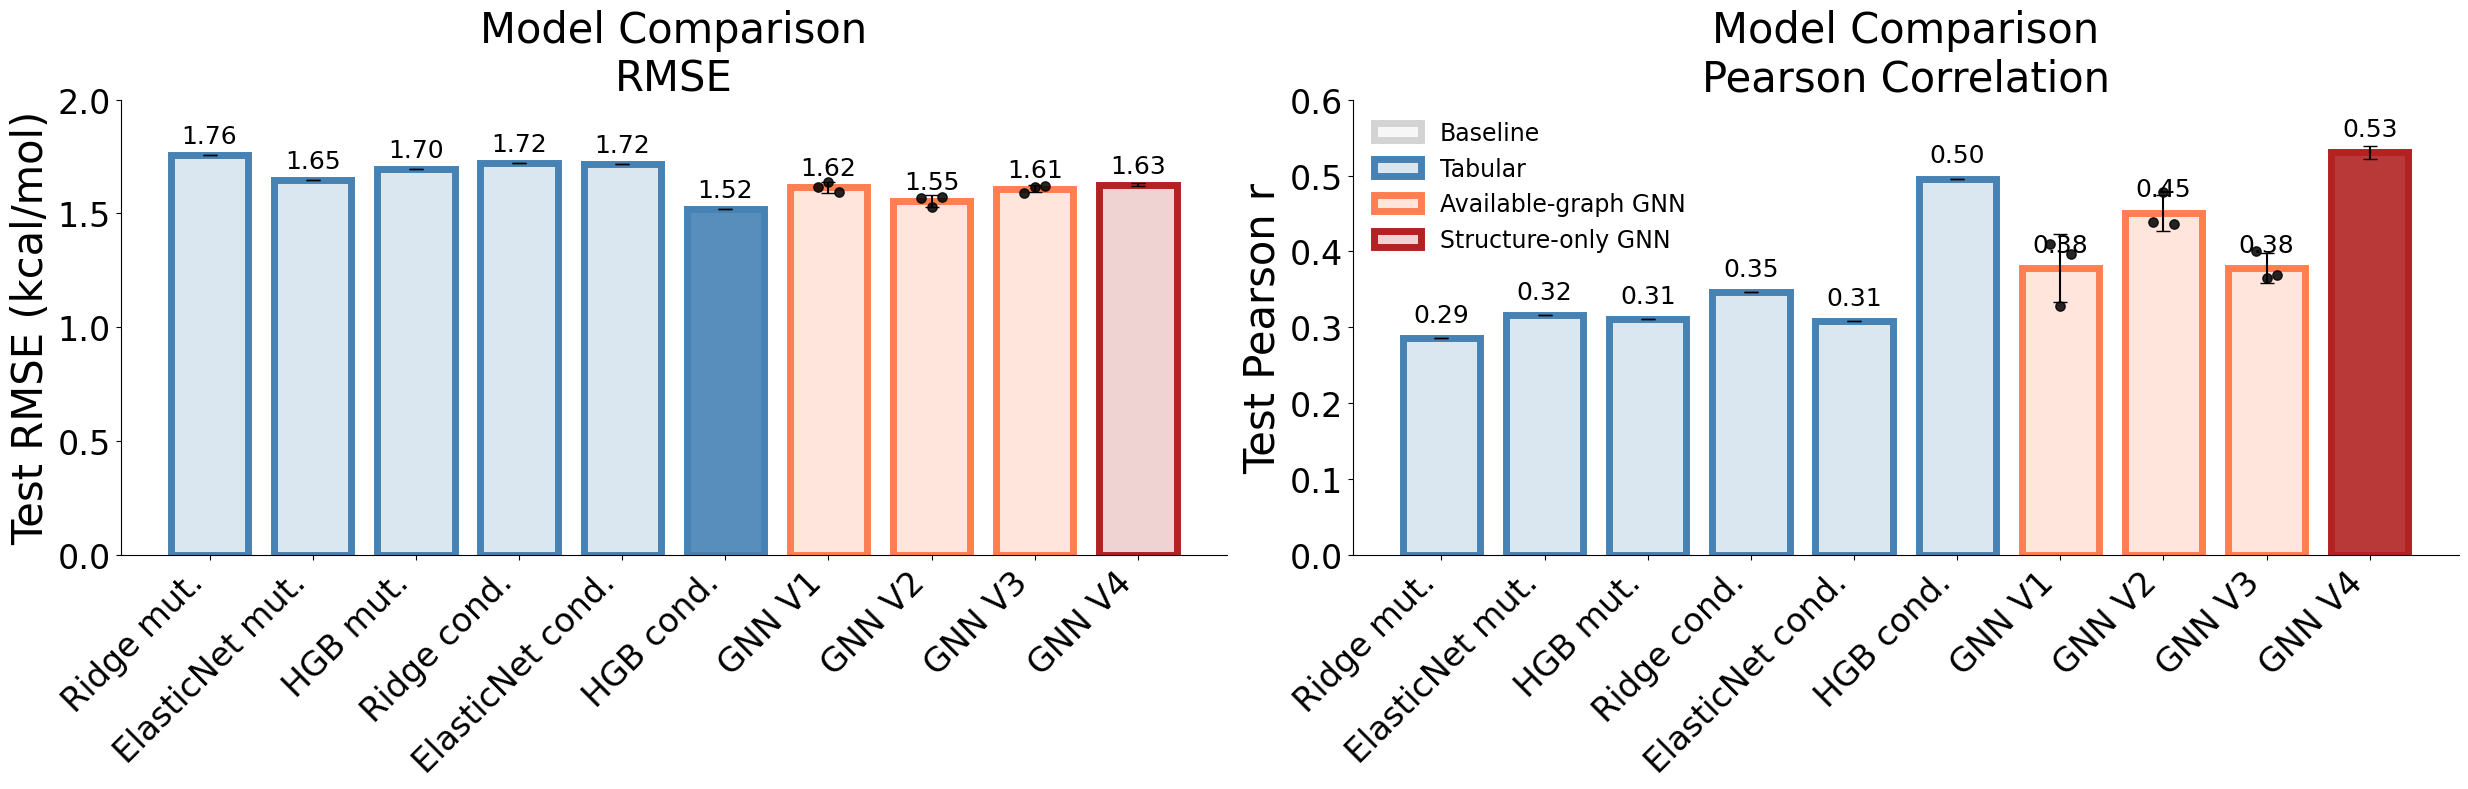

In [73]:
fig_width = 25
fig_height = 8
bar_width = 0.75
bar_linewidth = 5
default_alpha = 0.20
highlight_alpha = 0.90
seed_point_size = 45
seed_point_alpha = 0.85
x_label_fontsize = 24
y_label_fontsize = 30
title_fontsize = 30
tick_fontsize = 24
legend_fontsize = 17
value_fontsize = 18
label_rotation = 45

model_order = [
    "Mean baseline",
    "Ridge (mutation_only)",
    "ElasticNet (mutation_only)",
    "HistGradientBoosting (mutation_only)",
    "Ridge (condition_aware)",
    "ElasticNet (condition_aware)",
    "HistGradientBoosting (condition_aware)",
    "V1 local_delta available-graph GNN",
    "V2 local_delta + condition feats available-graph GNN",
    "V3 local + global + condition feats available-graph GNN",
    "V4 structure-only distance-aware GNN",
]

label_map = {
    "Mean baseline": "Mean",
    "Ridge (mutation_only)": "Ridge mut.",
    "ElasticNet (mutation_only)": "ElasticNet mut.",
    "HistGradientBoosting (mutation_only)": "HGB mut.",
    "Ridge (condition_aware)": "Ridge cond.",
    "ElasticNet (condition_aware)": "ElasticNet cond.",
    "HistGradientBoosting (condition_aware)": "HGB cond.",
    "V1 local_delta available-graph GNN": "GNN V1",
    "V2 local_delta + condition feats available-graph GNN": "GNN V2",
    "V3 local + global + condition feats available-graph GNN": "GNN V3",
    "V4 structure-only distance-aware GNN": "GNN V4",
}

family_colors = {
    "baseline": "lightgray",
    "tabular": "steelblue",
    "available_graph_gnn": "coral",
    "structure_gnn": "firebrick",
}

plot_df = model_comparison.copy()
plot_df = plot_df[plot_df["model"].isin(model_order)].copy()
plot_df = plot_df[plot_df["model"] != "Mean baseline"].copy()
plot_df["order"] = plot_df["model"].map({m: i for i, m in enumerate(model_order)})
plot_df = plot_df.sort_values("order").reset_index(drop=True)

x = np.arange(len(plot_df))
xticklabels = [label_map.get(m, m) for m in plot_df["model"]]

best_rmse_model = plot_df.loc[plot_df["test_rmse_mean"].idxmin(), "model"]
best_r_model = plot_df.loc[plot_df["test_r_mean"].idxmax(), "model"]

rmse_facecolors = [
    mcolors.to_rgba(family_colors.get(f, "gray"), alpha=highlight_alpha if m == best_rmse_model else default_alpha)
    for f, m in zip(plot_df["family"], plot_df["model"])
]
r_facecolors = [
    mcolors.to_rgba(family_colors.get(f, "gray"), alpha=highlight_alpha if m == best_r_model else default_alpha)
    for f, m in zip(plot_df["family"], plot_df["model"])
]

fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

ax = axes[0]
ax.bar(
    x, plot_df["test_rmse_mean"], yerr=plot_df["test_rmse_std"].fillna(0), color=rmse_facecolors,
    edgecolor=[family_colors.get(f, "gray") for f in plot_df["family"]], linewidth=bar_linewidth,
    width=bar_width, capsize=5
)

if "gnn_seed_results" in globals():
    gnn_x_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in gnn_x_lookup:
            continue
        xpos = gnn_x_lookup[model_name]
        jitter = np.linspace(-0.10, 0.10, len(group))
        ax.scatter(xpos + jitter, group["test_rmse"], color="black", s=seed_point_size, zorder=5, alpha=seed_point_alpha)

for xi, yi in zip(x, plot_df["test_rmse_mean"]):
    ax.text(xi, yi + 0.03, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=x_label_fontsize, rotation=label_rotation, ha="right")
ax.set_ylabel("Test RMSE (kcal/mol)", fontsize=y_label_fontsize)
ax.set_title("Model Comparison\nRMSE", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0,2)

ax = axes[1]
ax.bar(
    x, plot_df["test_r_mean"], yerr=plot_df["test_r_std"].fillna(0), color=r_facecolors,
    edgecolor=[family_colors.get(f, "gray") for f in plot_df["family"]], linewidth=bar_linewidth,
    width=bar_width, capsize=5
)

if "gnn_seed_results" in globals():
    gnn_x_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in gnn_x_lookup:
            continue
        xpos = gnn_x_lookup[model_name]
        jitter = np.linspace(-0.10, 0.10, len(group))
        ax.scatter(xpos + jitter, group["test_r"], color="black", s=seed_point_size, zorder=5, alpha=seed_point_alpha)

for xi, yi in zip(x, plot_df["test_r_mean"]):
    ax.text(xi, yi + 0.015, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=x_label_fontsize, rotation=label_rotation, ha="right")
ax.set_ylabel("Test Pearson r", fontsize=y_label_fontsize)
ax.set_title("Model Comparison\nPearson Correlation", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0,0.6)

legend_handles = [
    Patch(facecolor=mcolors.to_rgba("lightgray", alpha=default_alpha), edgecolor="lightgray", linewidth=bar_linewidth, label="Baseline"),
    Patch(facecolor=mcolors.to_rgba("steelblue", alpha=default_alpha), edgecolor="steelblue", linewidth=bar_linewidth, label="Tabular"),
    Patch(facecolor=mcolors.to_rgba("coral", alpha=default_alpha), edgecolor="coral", linewidth=bar_linewidth, label="Available-graph GNN"),
    Patch(facecolor=mcolors.to_rgba("firebrick", alpha=default_alpha), edgecolor="firebrick", linewidth=bar_linewidth, label="Structure-only GNN"),
]

axes[1].legend(handles=legend_handles, fontsize=legend_fontsize, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

### 3. Prediction behavior: best tabular model vs best GNN
This shows whether the models are learning the full ΔΔG range or shrinking predictions toward the mean.


Interesting interpretation of this plot!!

The models are not random because we know that Pearson r around 0.50 and 0.44. This means that they capture some ordering. However they are conservative: they compress predictions toward the middle and fail to capture extreme ΔΔG values. The GNN is slightly worse here because its predictions are even more compressed than the tabular model.

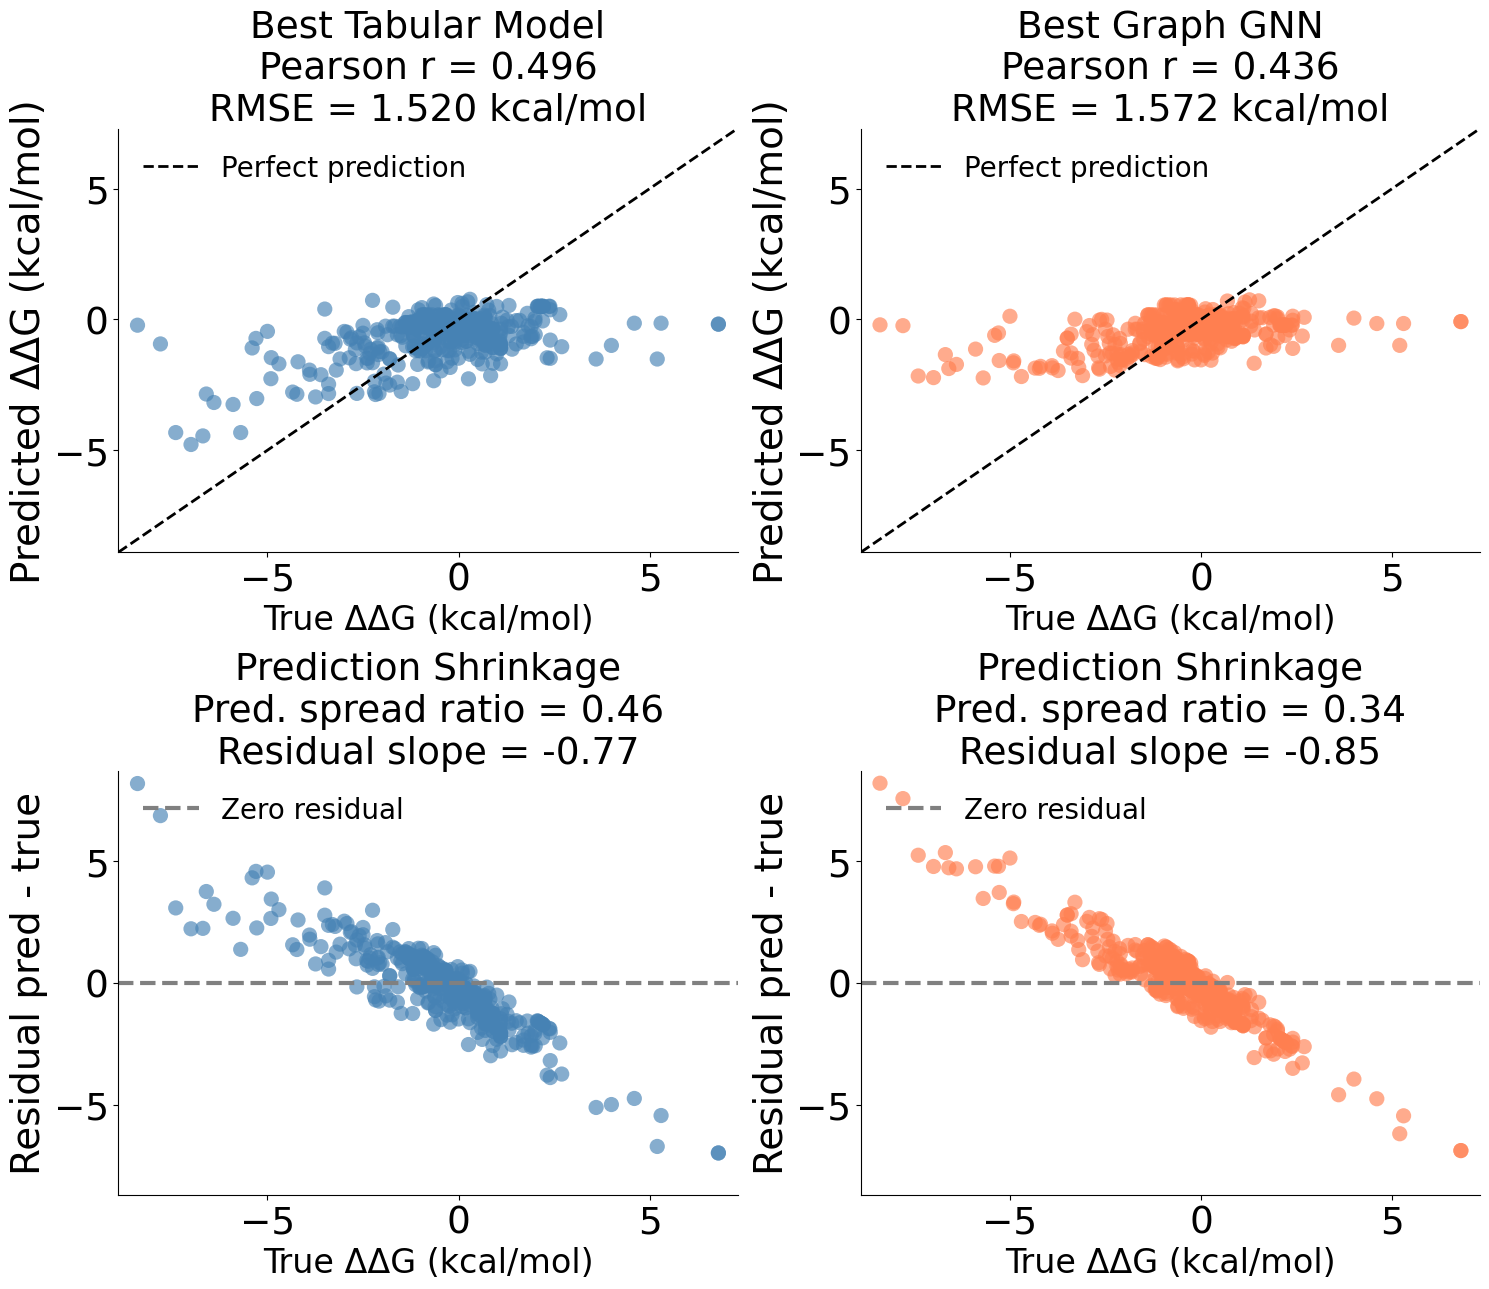

Best tabular model: HistGradientBoosting (condition_aware)
Best available-graph GNN: V2 local_delta + condition feats available-graph GNN


In [80]:
fig_width = 15
fig_height = 13
scatter_size = 120
scatter_alpha = 0.55
line_width = 3
perfect_linewidth = 2
zero_linewidth = 3
x_label_fontsize = 24
y_label_fontsize = 28
title_fontsize = 27
tick_fontsize = 27
legend_fontsize = 20
tabular_color = "steelblue"
gnn_color = "coral"
tabular_alpha = 0.65
gnn_alpha = 0.65

best_tabular_model = model_comparison[model_comparison["family"].eq("tabular")].sort_values("test_rmse_mean").iloc[0]["model"]
best_gnn_model = model_comparison[model_comparison["family"].eq("available_graph_gnn")].sort_values("test_rmse_mean").iloc[0]["model"]

model_specs = [
    (best_tabular_model, "Best Tabular Model", tabular_color, tabular_alpha),
    (best_gnn_model, "Best Graph GNN", gnn_color, gnn_alpha),
]

def get_test_predictions(model_name):
    out = all_predictions[(all_predictions["model"].eq(model_name)) & (all_predictions["split"].eq("test"))].copy().reset_index(drop=True)
    y_true = out["y_true"].to_numpy(dtype=float)
    y_pred = out["y_pred"].to_numpy(dtype=float)
    residual = y_pred - y_true
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r = pearsonr(y_true, y_pred)[0] if len(y_true) > 2 else np.nan
    pred_std_ratio = np.std(y_pred) / np.std(y_true) if np.std(y_true) > 0 else np.nan
    residual_slope = np.polyfit(y_true, residual, 1)[0] if len(y_true) > 2 else np.nan
    return out, y_true, y_pred, residual, rmse, r, pred_std_ratio, residual_slope

loaded = {}
for model_name, display_name, color, alpha in model_specs:
    loaded[model_name] = get_test_predictions(model_name)

all_y_true = np.concatenate([loaded[m[0]][1] for m in model_specs])
all_y_pred = np.concatenate([loaded[m[0]][2] for m in model_specs])
all_resid = np.concatenate([loaded[m[0]][3] for m in model_specs])

pred_lo = float(min(all_y_true.min(), all_y_pred.min())) - 0.5
pred_hi = float(max(all_y_true.max(), all_y_pred.max())) + 0.5
resid_abs = float(np.nanmax(np.abs(all_resid))) + 0.5

fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))

for col_idx, (model_name, display_name, color, alpha) in enumerate(model_specs):
    out, y_true, y_pred, residual, rmse, r, pred_std_ratio, residual_slope = loaded[model_name]
    ax = axes[0, col_idx]
    ax.scatter(y_true, y_pred, s=scatter_size, color=mcolors.to_rgba(color, alpha=alpha), edgecolors="none")
    ax.plot([pred_lo, pred_hi], [pred_lo, pred_hi], "k--", linewidth=perfect_linewidth, label="Perfect prediction")
    ax.set_xlim(pred_lo, pred_hi)
    ax.set_ylim(pred_lo, pred_hi)
    ax.set_xlabel("True ΔΔG (kcal/mol)", fontsize=x_label_fontsize)
    ax.set_ylabel("Predicted ΔΔG (kcal/mol)", fontsize=y_label_fontsize)
    ax.set_title(f"{display_name}\nPearson r = {r:.3f}\nRMSE = {rmse:.3f} kcal/mol", fontsize=title_fontsize)
    ax.legend(fontsize=legend_fontsize, frameon=False, loc="upper left")
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for col_idx, (model_name, display_name, color, alpha) in enumerate(model_specs):
    out, y_true, y_pred, residual, rmse, r, pred_std_ratio, residual_slope = loaded[model_name]
    ax = axes[1, col_idx]
    ax.scatter(y_true, residual, s=scatter_size, color=mcolors.to_rgba(color, alpha=alpha), edgecolors="none")
    ax.axhline(0, color="gray", linestyle="--", linewidth=zero_linewidth, label="Zero residual")
    ax.set_xlim(pred_lo, pred_hi)
    ax.set_ylim(-resid_abs, resid_abs)
    ax.set_xlabel("True ΔΔG (kcal/mol)", fontsize=x_label_fontsize)
    ax.set_ylabel("Residual pred - true", fontsize=y_label_fontsize)
    ax.set_title(f"Prediction Shrinkage\nPred. spread ratio = {pred_std_ratio:.2f}\nResidual slope = {residual_slope:.2f}", fontsize=title_fontsize)
    ax.legend(fontsize=legend_fontsize, frameon=False, loc="upper left")
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Best tabular model:", best_tabular_model)
# fig.savefig(PROJECT_ROOT / "assets" / "figures" / "gnn_main2_prediction_behavior", dpi=300, bbox_inches="tight")
print("Best available-graph GNN:", best_gnn_model)

### 4. GNN architecture/readout ablation
Which additions to the GNN helped: condition features, global graph pooling, or structure-only filtering?

Most useful addition to the GNN was not more global graph context — it was adding condition/mutation-level features to the local graph representation

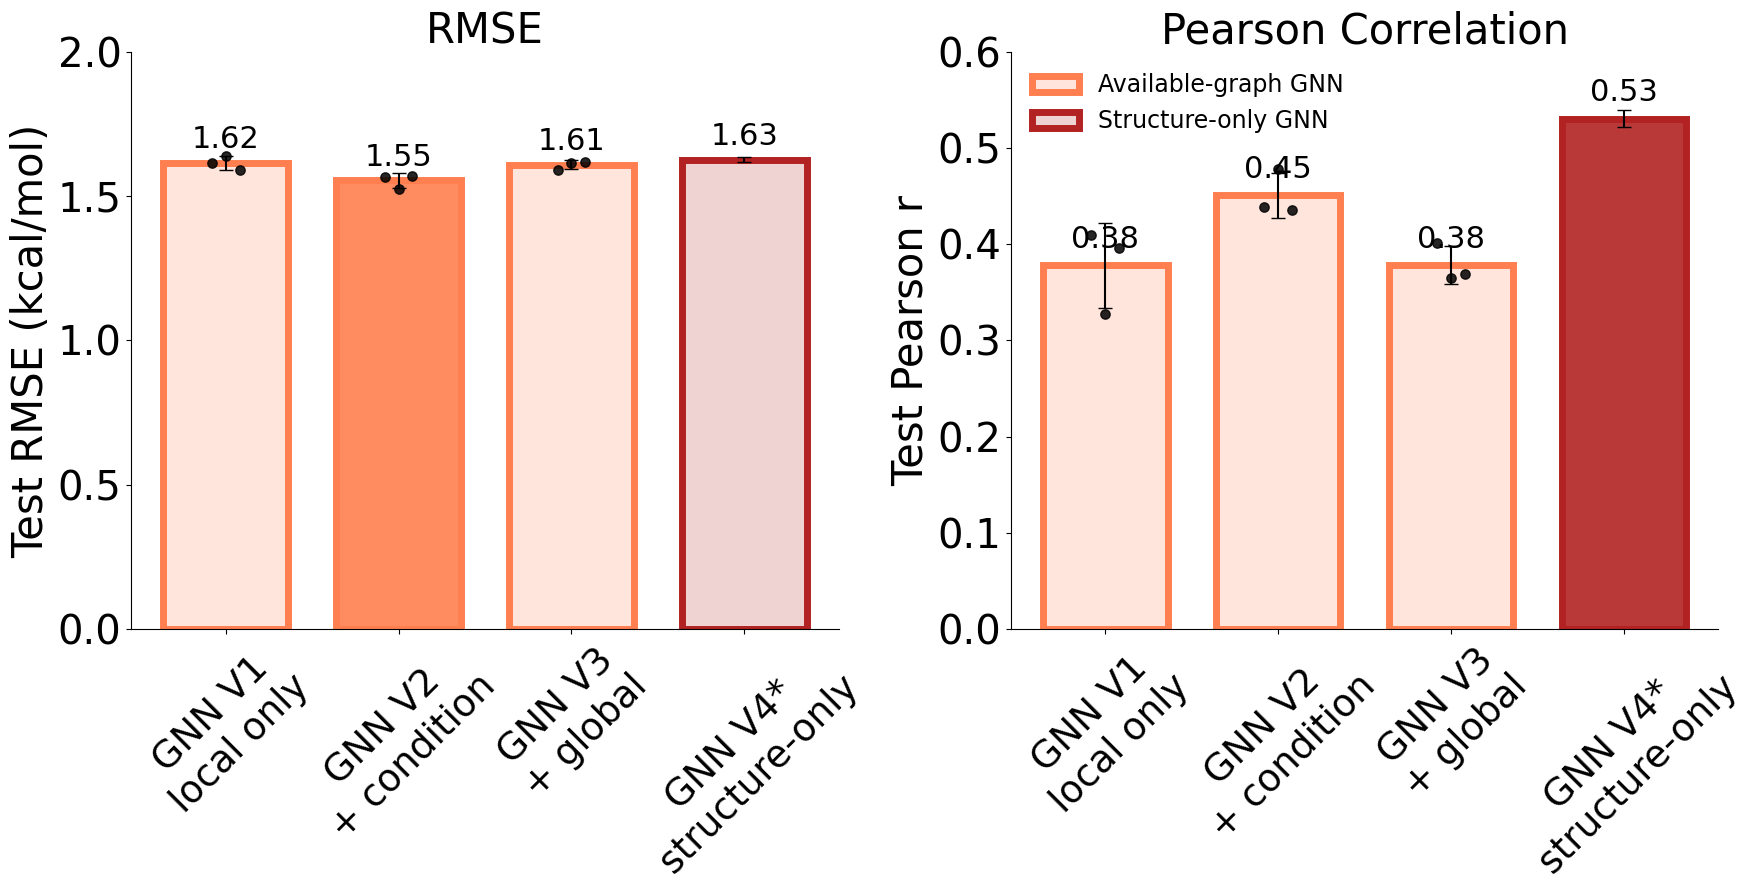

In [90]:
fig_width = 18
fig_height = 9
bar_width = 0.72
bar_linewidth = 5
default_alpha = 0.20
highlight_alpha = 0.90
seed_point_size = 45
seed_point_alpha = 0.85
x_label_fontsize = 27
y_label_fontsize = 30
title_fontsize = 30
tick_fontsize = 29
legend_fontsize = 17
value_fontsize = 22
label_rotation = 45

gnn_order = [
    "V1 local_delta available-graph GNN",
    "V2 local_delta + condition feats available-graph GNN",
    "V3 local + global + condition feats available-graph GNN",
    "V4 structure-only distance-aware GNN",
]

label_map = {
    "V1 local_delta available-graph GNN": "GNN V1\nlocal only",
    "V2 local_delta + condition feats available-graph GNN": "GNN V2\n+ condition",
    "V3 local + global + condition feats available-graph GNN": "GNN V3\n+ global",
    "V4 structure-only distance-aware GNN": "GNN V4*\nstructure-only",
}

edge_colors = {
    "V1 local_delta available-graph GNN": "coral",
    "V2 local_delta + condition feats available-graph GNN": "coral",
    "V3 local + global + condition feats available-graph GNN": "coral",
    "V4 structure-only distance-aware GNN": "firebrick",
}

plot_df = model_comparison.copy()
plot_df = plot_df[plot_df["model"].isin(gnn_order)].copy()
plot_df["order"] = plot_df["model"].map({m: i for i, m in enumerate(gnn_order)})
plot_df = plot_df.sort_values("order").reset_index(drop=True)

x = np.arange(len(plot_df))
xticklabels = [label_map.get(m, m) for m in plot_df["model"]]

best_rmse_model = plot_df.loc[plot_df["test_rmse_mean"].idxmin(), "model"]
best_r_model = plot_df.loc[plot_df["test_r_mean"].idxmax(), "model"]

rmse_facecolors = [
    mcolors.to_rgba(edge_colors[m], alpha=highlight_alpha if m == best_rmse_model else default_alpha)
    for m in plot_df["model"]
]
r_facecolors = [
    mcolors.to_rgba(edge_colors[m], alpha=highlight_alpha if m == best_r_model else default_alpha)
    for m in plot_df["model"]
]

fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

ax = axes[0]
ax.bar(
    x, plot_df["test_rmse_mean"], yerr=plot_df["test_rmse_std"].fillna(0), color=rmse_facecolors,
    edgecolor=[edge_colors[m] for m in plot_df["model"]], linewidth=bar_linewidth,
    width=bar_width, capsize=5
)

if "gnn_seed_results" in globals():
    seed_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in seed_lookup:
            continue
        xpos = seed_lookup[model_name]
        jitter = np.linspace(-0.08, 0.08, len(group))
        ax.scatter(xpos + jitter, group["test_rmse"], color="black", s=seed_point_size, zorder=5, alpha=seed_point_alpha)

for xi, yi in zip(x, plot_df["test_rmse_mean"]):
    ax.text(xi, yi + 0.03, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=x_label_fontsize, rotation=label_rotation, ha="center")
ax.set_ylabel("Test RMSE (kcal/mol)", fontsize=y_label_fontsize)
ax.set_title("RMSE", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 2)

ax = axes[1]
ax.bar(
    x, plot_df["test_r_mean"], yerr=plot_df["test_r_std"].fillna(0), color=r_facecolors,
    edgecolor=[edge_colors[m] for m in plot_df["model"]], linewidth=bar_linewidth,
    width=bar_width, capsize=5
)

if "gnn_seed_results" in globals():
    seed_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in seed_lookup:
            continue
        xpos = seed_lookup[model_name]
        jitter = np.linspace(-0.08, 0.08, len(group))
        ax.scatter(xpos + jitter, group["test_r"], color="black", s=seed_point_size, zorder=5, alpha=seed_point_alpha)

for xi, yi in zip(x, plot_df["test_r_mean"]):
    ax.text(xi, yi + 0.012, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=x_label_fontsize, rotation=label_rotation, ha="center")
ax.set_ylabel("Test Pearson r", fontsize=y_label_fontsize)
ax.set_title("Pearson Correlation", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 0.6)

legend_handles = [
    Patch(facecolor=mcolors.to_rgba("coral", alpha=default_alpha), edgecolor="coral", linewidth=bar_linewidth, label="Available-graph GNN"),
    Patch(facecolor=mcolors.to_rgba("firebrick", alpha=default_alpha), edgecolor="firebrick", linewidth=bar_linewidth, label="Structure-only GNN"),
]

axes[1].legend(handles=legend_handles, fontsize=legend_fontsize, frameon=False, loc="upper left")

plt.tight_layout()
# fig.savefig(PROJECT_ROOT / "assets" / "figures" / "gnn_ablation_architecture", dpi=300, bbox_inches="tight")
plt.show()

### 5. Training curves

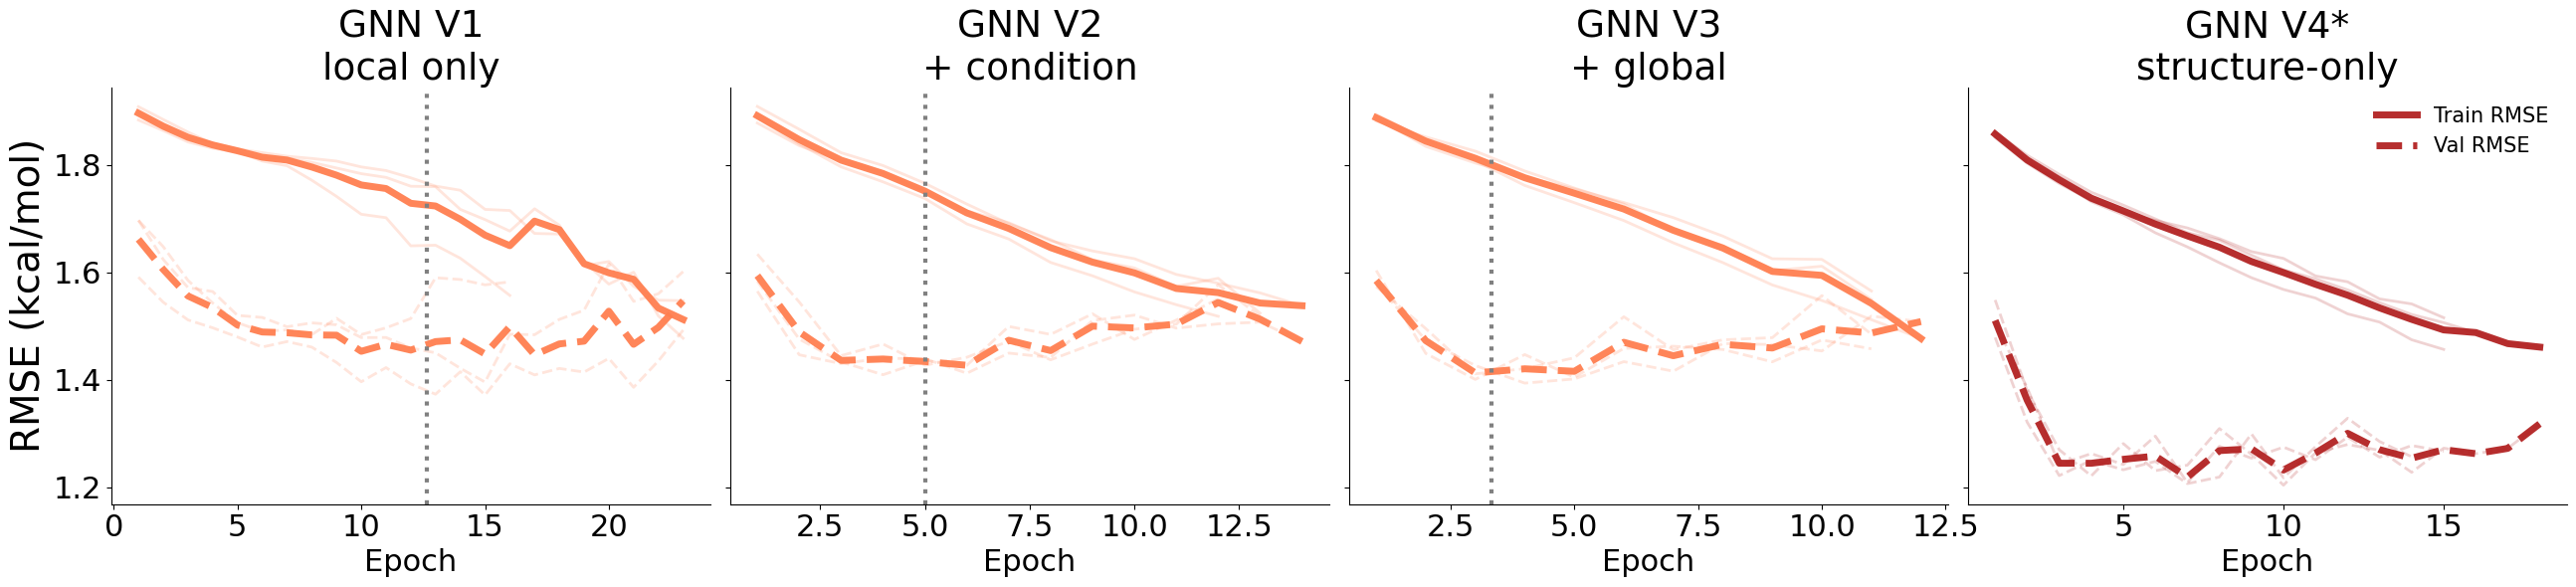

In [91]:
fig_width = 26
fig_height = 6
line_width = 5
seed_line_width = 2
seed_alpha = 0.20
mean_alpha = 0.95
best_linewidth = 3
x_label_fontsize = 22
y_label_fontsize = 28
title_fontsize = 27
tick_fontsize = 22
legend_fontsize = 15

version_order = [
    "V1 local_delta available-graph GNN",
    "V2 local_delta + condition feats available-graph GNN",
    "V3 local + global + condition feats available-graph GNN",
    "V4 structure-only distance-aware GNN",
]

title_map = {
    "V1 local_delta available-graph GNN": "GNN V1\nlocal only",
    "V2 local_delta + condition feats available-graph GNN": "GNN V2\n+ condition",
    "V3 local + global + condition feats available-graph GNN": "GNN V3\n+ global",
    "V4 structure-only distance-aware GNN": "GNN V4*\nstructure-only",
}

color_map = {
    "V1 local_delta available-graph GNN": "coral",
    "V2 local_delta + condition feats available-graph GNN": "coral",
    "V3 local + global + condition feats available-graph GNN": "coral",
    "V4 structure-only distance-aware GNN": "firebrick",
}

plot_versions = [v for v in version_order if v in training_history["version"].unique()]

fig, axes = plt.subplots(1, len(plot_versions), figsize=(fig_width, fig_height), sharey=True)

if len(plot_versions) == 1:
    axes = [axes]

for ax, version in zip(axes, plot_versions):
    sub = training_history[training_history["version"].eq(version)].copy()
    color = color_map.get(version, "gray")

    for seed, seed_df in sub.groupby("seed"):
        seed_df = seed_df.sort_values("epoch")
        ax.plot(seed_df["epoch"], seed_df["train_rmse"], color=color, linestyle="-", linewidth=seed_line_width, alpha=seed_alpha)
        ax.plot(seed_df["epoch"], seed_df["val_rmse"], color=color, linestyle="--", linewidth=seed_line_width, alpha=seed_alpha)

    mean_df = sub.groupby("epoch", as_index=False)[["train_rmse", "val_rmse"]].mean()
    ax.plot(mean_df["epoch"], mean_df["train_rmse"], color=color, linestyle="-", linewidth=line_width, alpha=mean_alpha, label="Train RMSE")
    ax.plot(mean_df["epoch"], mean_df["val_rmse"], color=color, linestyle="--", linewidth=line_width, alpha=mean_alpha, label="Val RMSE")

    if "gnn_seed_results" in globals():
        best_epoch_rows = gnn_seed_results[gnn_seed_results["version"].eq(version)]
        if len(best_epoch_rows) > 0:
            best_epoch = best_epoch_rows["best_epoch"].mean()
            ax.axvline(best_epoch, color="gray", linestyle=":", linewidth=best_linewidth, label=f"Mean best epoch ({best_epoch:.1f})")

    ax.set_xlabel("Epoch", fontsize=x_label_fontsize)
    ax.set_title(title_map.get(version, version), fontsize=title_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("RMSE (kcal/mol)", fontsize=y_label_fontsize)
axes[-1].legend(fontsize=legend_fontsize, frameon=False, loc="upper right")

plt.tight_layout()
# fig.savefig(PROJECT_ROOT / "assets" / "figures" / "gnn_training_curves", dpi=300, bbox_inches="tight")
plt.show()

validation selects very early epochs, suggesting limited useful capacity/data signal and possible underfitting/prediction shrinkage

In [64]:
display(gnn_seed_results[["version", "seed", "best_epoch", "train_rmse", "val_rmse", "test_rmse", "test_r"]])

,version,seed,best_epoch,train_rmse,val_rmse,test_rmse,test_r
0,V1 local_delta available-graph GNN,42,8,1.771631,1.484060,1.614399,0.410070
1,V1 local_delta available-graph GNN,43,15,1.717308,1.396003,1.639071,0.327671
2,V1 local_delta available-graph GNN,44,15,1.698285,1.371897,1.592165,0.396658
3,V2 local_delta + condition feats available-gra...,42,5,1.765804,1.427378,1.565790,0.439007
4,V2 local_delta + condition feats available-gra...,43,6,1.714625,1.412420,1.526446,0.477877
5,V2 local_delta + condition feats available-gra...,44,4,1.768543,1.409618,1.571767,0.435507
6,V3 local + global + condition feats available-...,42,4,1.761847,1.394015,1.590558,0.400876
7,V3 local + global + condition feats available-...,43,3,1.825698,1.411301,1.616208,0.364555
8,V3 local + global + condition feats available-...,44,3,1.803620,1.400922,1.620292,0.369562


### 6. Structural-context ablation: buried vs exposed residues
Does graph structure help more for buried residues, where contact networks should matter most?

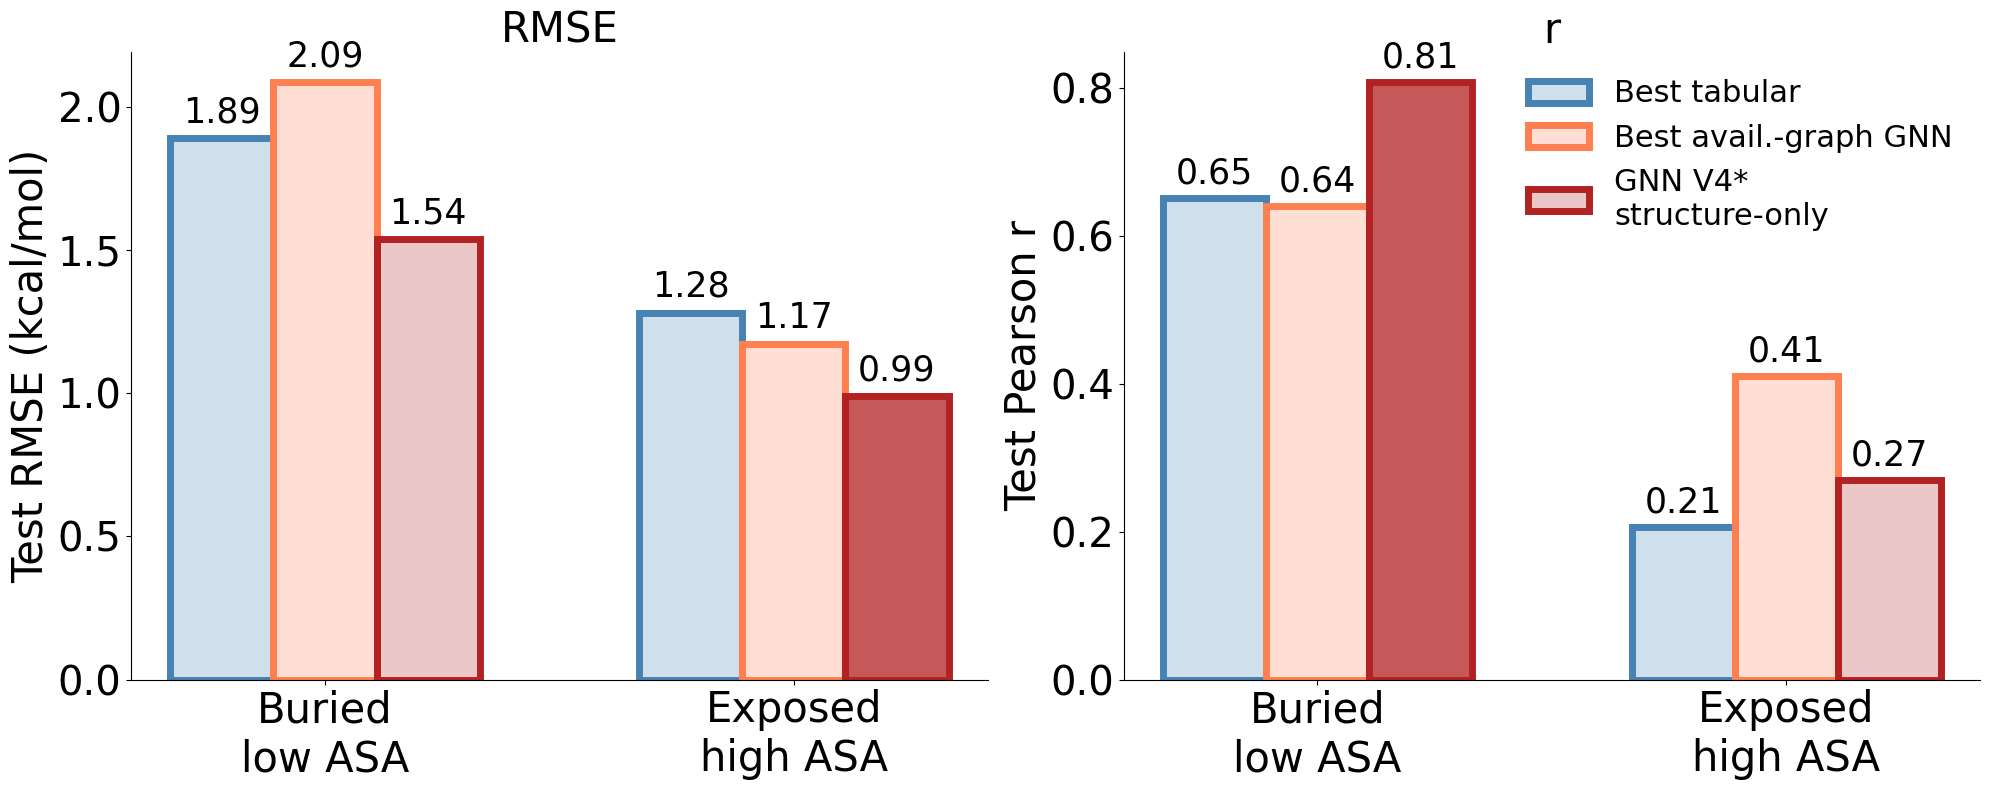

In [97]:
fig_width = 20
fig_height = 8
bar_width = 0.22
bar_linewidth = 5
default_alpha = 0.25
highlight_alpha = 0.75
x_label_fontsize = 30
y_label_fontsize = 30
title_fontsize = 30
tick_fontsize = 29
legend_fontsize = 22
value_fontsize = 25
label_rotation = 0

best_tabular_model = model_comparison[model_comparison["family"].eq("tabular")].sort_values("test_rmse_mean").iloc[0]["model"]
best_gnn_model = model_comparison[model_comparison["family"].eq("available_graph_gnn")].sort_values("test_rmse_mean").iloc[0]["model"]

model_order = [best_tabular_model, best_gnn_model]
if "V4 structure-only distance-aware GNN" in asa_stratified_results["model"].unique():
    model_order.append("V4 structure-only distance-aware GNN")

label_map = {
    best_tabular_model: "Best tabular",
    best_gnn_model: "Best avail.-graph GNN",
    "V4 structure-only distance-aware GNN": "GNN V4*\nstructure-only",
}

edge_colors = {
    best_tabular_model: "steelblue",
    best_gnn_model: "coral",
    "V4 structure-only distance-aware GNN": "firebrick",
}

context_order = ["buried/low_ASA", "exposed/high_ASA"]
context_label_map = {
    "buried/low_ASA": "Buried\nlow ASA",
    "exposed/high_ASA": "Exposed\nhigh ASA",
}

plot_df = asa_stratified_results.copy()
plot_df = plot_df[plot_df["model"].isin(model_order)].copy()
plot_df = plot_df[plot_df["asa_context"].isin(context_order)].copy()

x = np.arange(len(context_order))
offsets = np.linspace(-bar_width, bar_width, len(model_order))

best_rmse_idx = plot_df["rmse"].idxmin()
best_r_idx = plot_df["r"].idxmax()
best_rmse_key = (plot_df.loc[best_rmse_idx, "model"], plot_df.loc[best_rmse_idx, "asa_context"])
best_r_key = (plot_df.loc[best_r_idx, "model"], plot_df.loc[best_r_idx, "asa_context"])

fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

ax = axes[0]
for offset, model_name in zip(offsets, model_order):
    sub = plot_df[plot_df["model"].eq(model_name)].set_index("asa_context").loc[context_order].reset_index()
    facecolors = [
        mcolors.to_rgba(edge_colors[model_name], alpha=highlight_alpha if (model_name, ctx) == best_rmse_key else default_alpha)
        for ctx in sub["asa_context"]
    ]
    ax.bar(
        x + offset, sub["rmse"], color=facecolors, edgecolor=edge_colors[model_name], linewidth=bar_linewidth,
        width=bar_width, label=label_map[model_name]
    )
    for xi, yi in zip(x + offset, sub["rmse"]):
        ax.text(xi, yi + 0.03, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels([context_label_map[c] for c in context_order], fontsize=x_label_fontsize, rotation=label_rotation, ha="center")
ax.set_ylabel("Test RMSE (kcal/mol)", fontsize=y_label_fontsize)
ax.set_title("RMSE", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax = axes[1]
for offset, model_name in zip(offsets, model_order):
    sub = plot_df[plot_df["model"].eq(model_name)].set_index("asa_context").loc[context_order].reset_index()
    facecolors = [
        mcolors.to_rgba(edge_colors[model_name], alpha=highlight_alpha if (model_name, ctx) == best_r_key else default_alpha)
        for ctx in sub["asa_context"]
    ]
    ax.bar(
        x + offset, sub["r"], color=facecolors, edgecolor=edge_colors[model_name], linewidth=bar_linewidth,
        width=bar_width, label=label_map[model_name]
    )
    for xi, yi in zip(x + offset, sub["r"]):
        ax.text(xi, yi + 0.01, f"{yi:.2f}", ha="center", va="bottom", fontsize=value_fontsize)

ax.set_xticks(x)
ax.set_xticklabels([context_label_map[c] for c in context_order], fontsize=x_label_fontsize, rotation=label_rotation, ha="center")
ax.set_ylabel("Test Pearson r", fontsize=y_label_fontsize)
ax.set_title("r", fontsize=title_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(facecolor=mcolors.to_rgba(edge_colors[m], alpha=default_alpha), edgecolor=edge_colors[m], linewidth=bar_linewidth, label=label_map[m])
    for m in model_order
]

axes[1].legend(handles=legend_handles, fontsize=legend_fontsize, frameon=False, loc="upper right")

plt.tight_layout()
# fig.savefig(PROJECT_ROOT / "assets" / "figures" / "gnn_ablation_buried_exposed_ASA", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
display(
    asa_stratified_results[
        ["model", "asa_context", "n", "rmse", "r"]
    ].sort_values(["model", "asa_context"])
)

,model,asa_context,n,rmse,r
0,ElasticNet (condition_aware),buried/low_ASA,100,2.147217,0.678783
1,ElasticNet (condition_aware),exposed/high_ASA,112,1.252307,0.309048
2,ElasticNet (mutation_only),buried/low_ASA,100,2.225455,0.585045
3,ElasticNet (mutation_only),exposed/high_ASA,112,1.283012,0.182127
4,HistGradientBoosting (condition_aware),buried/low_ASA,100,1.890873,0.650338
5,HistGradientBoosting (condition_aware),exposed/high_ASA,112,1.281524,0.206884
6,HistGradientBoosting (mutation_only),buried/low_ASA,100,2.280484,0.355343
7,HistGradientBoosting (mutation_only),exposed/high_ASA,112,1.533641,0.207508
8,Ridge (condition_aware),buried/low_ASA,100,2.054335,0.669067
9,Ridge (condition_aware),exposed/high_ASA,112,1.258148,0.185138


### 7. Contact graph explorer
TESTING..

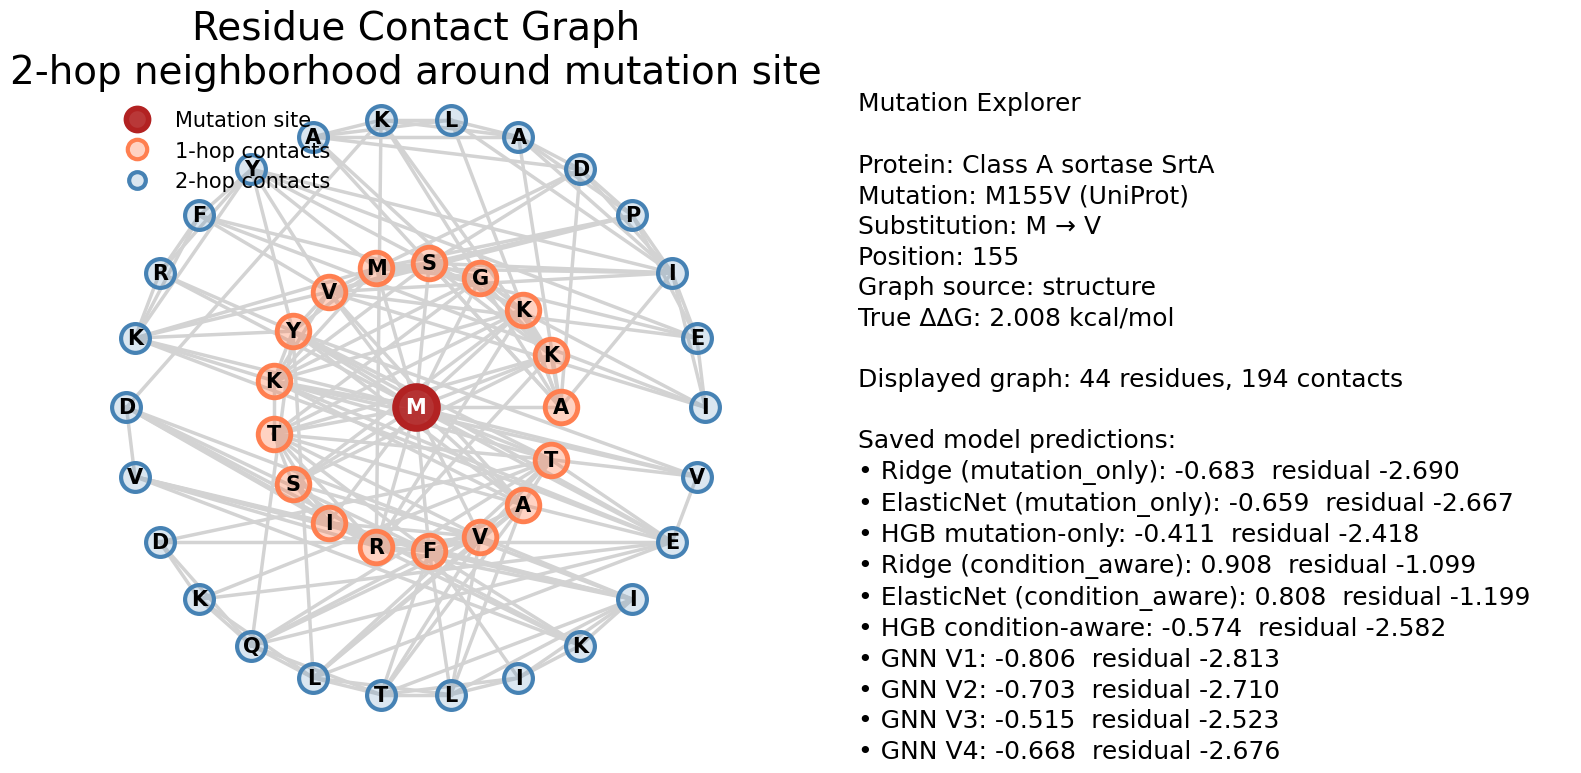

In [66]:
GNN_RUN_TAG = "final_main"

contact_graph_path = ASSETS_DIR / f"contact_graph_example_{GNN_RUN_TAG}.json"

with open(contact_graph_path, "r") as f:
    contact_graph_example = json.load(f)

def build_adjacency(edges):
    adj = {}
    for e in edges:
        a = int(e["source"])
        b = int(e["target"])
        adj.setdefault(a, set()).add(b)
        adj.setdefault(b, set()).add(a)
    return adj

def nodes_within_hops(adj, center, max_hops):
    visited = {center: 0}
    frontier = [center]
    for _ in range(max_hops):
        new_frontier = []
        for node in frontier:
            for nb in adj.get(node, []):
                if nb not in visited:
                    visited[nb] = visited[node] + 1
                    new_frontier.append(nb)
        frontier = new_frontier
    return visited

def make_radial_layout(hop_distances):
    layout = {}
    by_hop = {}
    for node, hop in hop_distances.items():
        by_hop.setdefault(hop, []).append(node)

    layout[min(hop_distances, key=hop_distances.get)] = (0.0, 0.0)

    for hop, nodes in by_hop.items():
        if hop == 0:
            continue
        nodes = sorted(nodes)
        radius = hop
        for i, node in enumerate(nodes):
            theta = 2 * np.pi * i / max(len(nodes), 1)
            layout[node] = (radius * np.cos(theta), radius * np.sin(theta))
    return layout

def short_model_name(name):
    replacements = {
        "HistGradientBoosting (condition_aware)": "HGB condition-aware",
        "HistGradientBoosting (mutation_only)": "HGB mutation-only",
        "V1 local_delta available-graph GNN": "GNN V1",
        "V2 local_delta + condition feats available-graph GNN": "GNN V2",
        "V3 local + global + condition feats available-graph GNN": "GNN V3",
        "V4 structure-only distance-aware GNN": "GNN V4",
    }
    return replacements.get(name, name)

def plot_contact_graph_example(payload, max_hops=2):
    nodes = payload["nodes"]
    edges = payload["edges"]
    node_by_id = {int(n["id"]): n for n in nodes}
    mutation_nodes = [int(n["id"]) for n in nodes if n.get("is_mutation_site", False)]

    if len(mutation_nodes) == 0:
        mutation_node = int(nodes[0]["id"])
    else:
        mutation_node = mutation_nodes[0]

    adj = build_adjacency(edges)
    hop_distances = nodes_within_hops(adj, mutation_node, max_hops=max_hops)
    selected_nodes = set(hop_distances.keys())
    selected_edges = [
        (int(e["source"]), int(e["target"]))
        for e in edges
        if int(e["source"]) in selected_nodes and int(e["target"]) in selected_nodes
    ]

    layout = make_radial_layout(hop_distances)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.35, 1]})
    ax = axes[0]
    info_ax = axes[1]

    for a, b in selected_edges:
        xa, ya = layout[a]
        xb, yb = layout[b]
        ax.plot([xa, xb], [ya, yb], color="lightgray", linewidth=2.5, zorder=1)

    for node_id in selected_nodes:
        x, y = layout[node_id]
        node = node_by_id[node_id]
        is_mut = bool(node.get("is_mutation_site", False))
        hop = hop_distances[node_id]

        if is_mut:
            facecolor = mcolors.to_rgba("firebrick", alpha=0.90)
            edgecolor = "firebrick"
            size = 900
            linewidth = 5
            label_color = "white"
        elif hop == 1:
            facecolor = mcolors.to_rgba("coral", alpha=0.35)
            edgecolor = "coral"
            size = 550
            linewidth = 3.5
            label_color = "black"
        else:
            facecolor = mcolors.to_rgba("steelblue", alpha=0.20)
            edgecolor = "steelblue"
            size = 430
            linewidth = 3
            label_color = "black"

        ax.scatter(x, y, s=size, color=facecolor, edgecolor=edgecolor, linewidth=linewidth, zorder=3)
        ax.text(x, y, node.get("aa", ""), ha="center", va="center", fontsize=15, color=label_color, fontweight="bold", zorder=4)

    ax.set_title(f"Residue Contact Graph\n{max_hops}-hop neighborhood around mutation site", fontsize=28)
    ax.set_aspect("equal")
    ax.axis("off")

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=mcolors.to_rgba("firebrick", alpha=0.90), markeredgecolor="firebrick", markeredgewidth=4, markersize=16, label="Mutation site"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=mcolors.to_rgba("coral", alpha=0.35), markeredgecolor="coral", markeredgewidth=3, markersize=14, label="1-hop contacts"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=mcolors.to_rgba("steelblue", alpha=0.20), markeredgecolor="steelblue", markeredgewidth=3, markersize=12, label="2-hop contacts"),
    ]
    ax.legend(handles=legend_handles, fontsize=15, frameon=False, loc="upper left")

    info_ax.axis("off")

    protein = payload.get("protein", "")
    mutation = payload.get("mutation", "")
    wt_aa = payload.get("wt_aa", "")
    mut_aa = payload.get("mut_aa", "")
    position = payload.get("position", "")
    true_ddg = payload.get("true_ddG", np.nan)
    graph_source = payload.get("graph_source", "unknown")

    lines = [
        "Mutation Explorer",
        "",
        f"Protein: {protein}",
        f"Mutation: {mutation}",
        f"Substitution: {wt_aa} → {mut_aa}",
        f"Position: {position}",
        f"Graph source: {graph_source}",
        f"True ΔΔG: {true_ddg:.3f} kcal/mol" if isinstance(true_ddg, (int, float)) and np.isfinite(true_ddg) else f"True ΔΔG: {true_ddg}",
        "",
        f"Displayed graph: {len(selected_nodes)} residues, {len(selected_edges)} contacts",
        "",
    ]

    model_predictions = payload.get("model_predictions", {})
    if len(model_predictions) > 0:
        lines.append("Saved model predictions:")
        for model_name, pred in model_predictions.items():
            if "test" not in pred and "y_pred" in pred:
                pred_val = pred["y_pred"]
                residual = pred.get("residual", np.nan)
                lines.append(f"• {short_model_name(model_name)}: {pred_val:.3f}  residual {residual:+.3f}")
            elif "y_pred" in pred:
                pred_val = pred["y_pred"]
                residual = pred.get("residual", np.nan)
                lines.append(f"• {short_model_name(model_name)}: {pred_val:.3f}  residual {residual:+.3f}")
    else:
        lines.append("Saved model predictions were not included in this JSON.")

    info_text = "\n".join(lines)

    info_ax.text(0.0, 1.0, info_text, ha="left", va="top", fontsize=18, linespacing=1.35)
    plt.tight_layout()
    plt.show()

plot_contact_graph_example(contact_graph_example, max_hops=2)

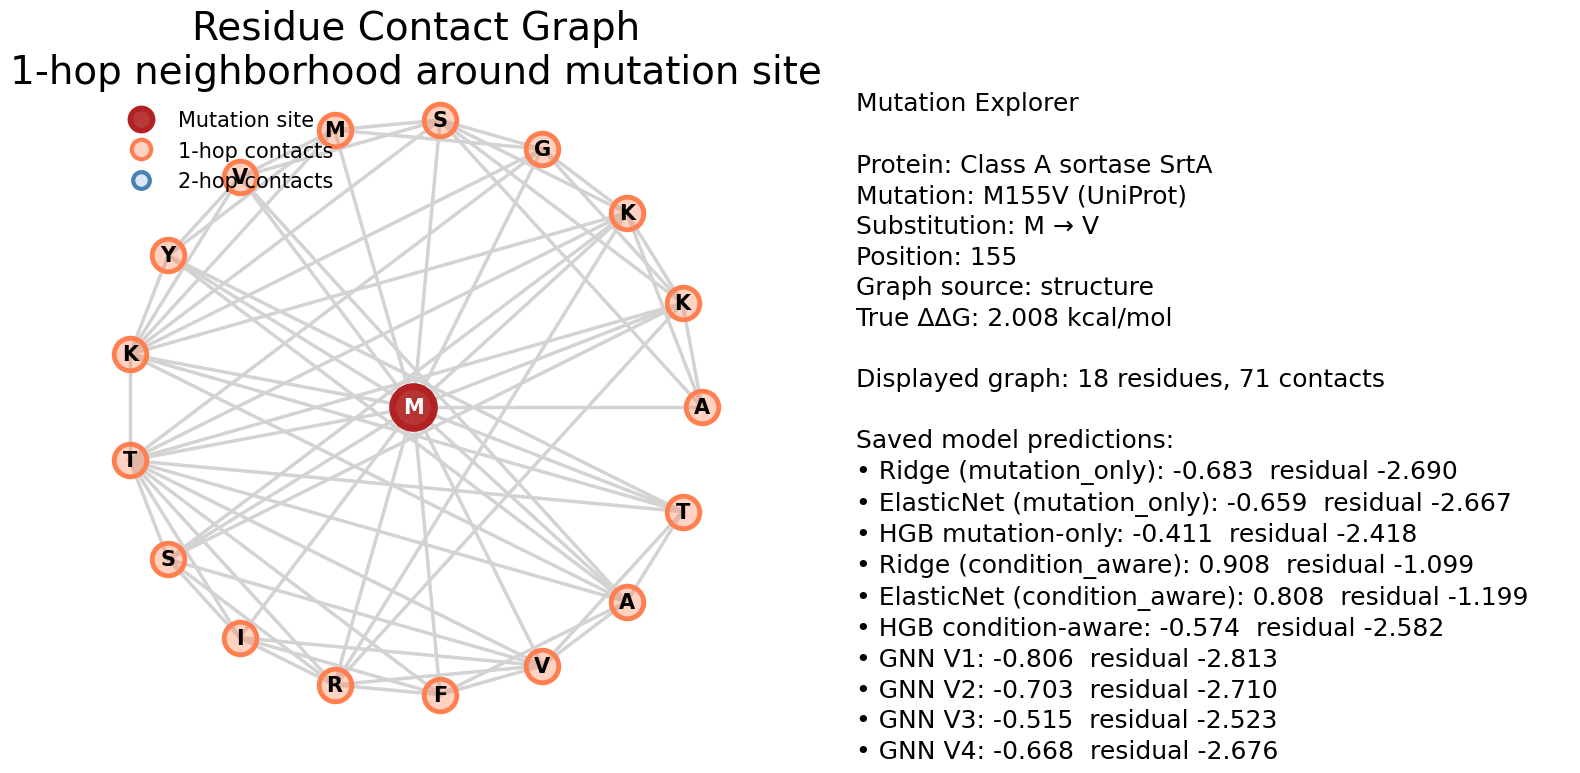

In [67]:
plot_contact_graph_example(contact_graph_example, max_hops=1)

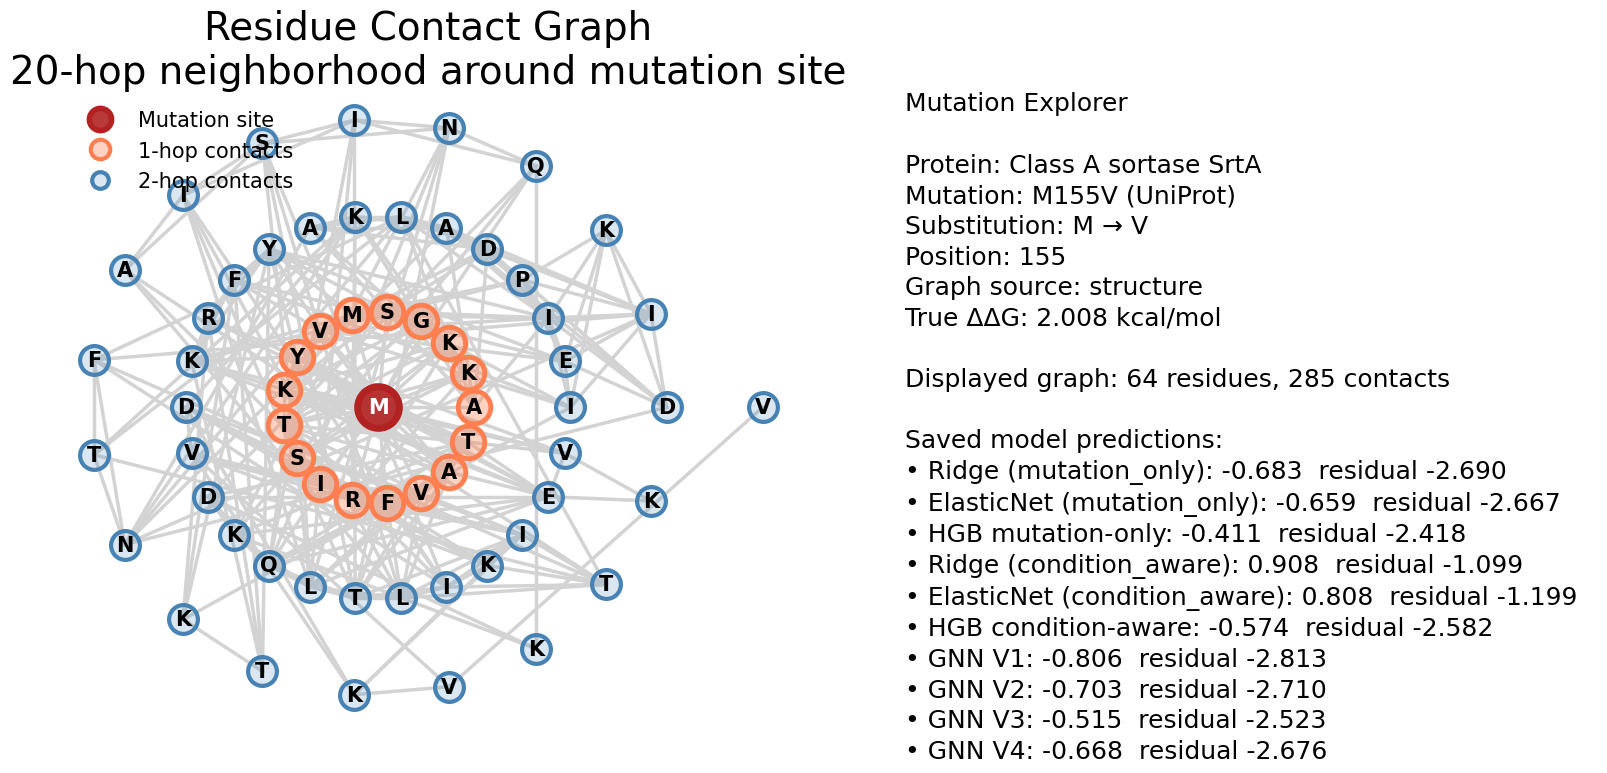

In [70]:
plot_contact_graph_example(contact_graph_example, max_hops=20)